# Построение рекомендательных систем "инвестор-актив" на основе матричных разложений и машинного обучения

## Установка и импорт библиотек

In [192]:
!pip install yfinance -q
!pip install scikit-surprise -q
!pip install optuna scikit-surprise -q
!pip install implicit -q
!pip install lightgbm -q

In [193]:
import os
import time
import warnings
from collections import defaultdict
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
import seaborn as sns
from surprise import Dataset, Reader, SVDpp
from sklearn.neighbors import NearestNeighbors
from surprise import SVD
import optuna
from surprise import NMF
from implicit.als import AlternatingLeastSquares
from implicit.bpr import BayesianPersonalizedRanking
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, normalize
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import lightgbm as lgb

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

## Загрузка данных FAR-Trans

In [3]:
!unzip FAR-Trans.zip

Archive:  FAR-Trans.zip
   creating: FAR-Trans/
  inflating: FAR-Trans/asset_information.csv  
  inflating: FAR-Trans/close_prices.csv  
  inflating: FAR-Trans/customer_information.csv  
  inflating: FAR-Trans/limit_prices.csv  
  inflating: FAR-Trans/markets.csv   
  inflating: FAR-Trans/questionnaires.csv  
  inflating: FAR-Trans/README.txt    
  inflating: FAR-Trans/transactions.csv  


In [4]:
path = "FAR-Trans/"

transactions = pd.read_csv(os.path.join(path, "transactions.csv"))
asset_information = pd.read_csv(os.path.join(path, "asset_information.csv"))
close_prices = pd.read_csv(os.path.join(path, "close_prices.csv"))
limit_prices = pd.read_csv(os.path.join(path, "limit_prices.csv"))
markets = pd.read_csv(os.path.join(path, "markets.csv"))
customer_information = pd.read_csv(os.path.join(path, "customer_information.csv"))
questionnaires_path = os.path.join(path, "questionnaires.csv")

with open(questionnaires_path, "r", encoding="utf-8") as file:
    questionnaires_text = file.read()

## Базовая информация по датасету


In [5]:
datasets = {
    "transactions": transactions,
    "asset_information": asset_information,
    "close_prices": close_prices,
    "limit_prices": limit_prices,
    "markets": markets,
    "customer_information": customer_information,
}

for name, df in datasets.items():
    print()
    print(name.upper())
    print("shape:", df.shape)
    print()
    print(df.columns.tolist())
    print()
    print(df.dtypes)
    print()


TRANSACTIONS
shape: (388048, 9)

['customerID', 'ISIN', 'transactionID', 'transactionType', 'timestamp', 'totalValue', 'units', 'channel', 'marketID']

customerID          object
ISIN                object
transactionID        int64
transactionType     object
timestamp           object
totalValue         float64
units              float64
channel             object
marketID            object
dtype: object


ASSET_INFORMATION
shape: (836, 9)

['ISIN', 'assetName', 'assetShortName', 'assetCategory', 'assetSubCategory', 'marketID', 'sector', 'industry', 'timestamp']

ISIN                object
assetName           object
assetShortName      object
assetCategory       object
assetSubCategory    object
marketID            object
sector              object
industry            object
timestamp           object
dtype: object


CLOSE_PRICES
shape: (703303, 3)

['ISIN', 'timestamp', 'closePrice']

ISIN           object
timestamp      object
closePrice    float64
dtype: object


LIMIT_PRICES
shap

In [6]:
transactions["timestamp"] = pd.to_datetime(transactions["timestamp"])

asset_information["timestamp"] = pd.to_datetime(asset_information["timestamp"])
close_prices["timestamp"] = pd.to_datetime(close_prices["timestamp"])
limit_prices["minDate"] = pd.to_datetime(limit_prices["minDate"])
limit_prices["maxDate"] = pd.to_datetime(limit_prices["maxDate"])
customer_information["timestamp"] = pd.to_datetime(customer_information["timestamp"])
customer_information["lastQuestionnaireDate"] = pd.to_datetime(customer_information["lastQuestionnaireDate"])

In [7]:
print("Период транзакций:")
print(f"{transactions['timestamp'].min().date()} - {transactions['timestamp'].max().date()}")
print("\nПериод цен:")
print(f"{close_prices['timestamp'].min().date()} - {close_prices['timestamp'].max().date()}")
print("\nПериод информации об активах:")
print(f"{asset_information['timestamp'].min().date()} - {asset_information['timestamp'].max().date()}")
print("\nПериод информации об инвесторах:")
print(f"{customer_information['timestamp'].min().date()} - {customer_information['timestamp'].max().date()}")
print("\nПериод расчета доходности активов:")
print(f"{limit_prices['minDate'].min().date()} - {limit_prices['maxDate'].max().date()}")

Период транзакций:
2018-01-02 - 2022-11-30

Период цен:
2018-01-01 - 2022-11-29

Период информации об активах:
2018-01-01 - 2022-10-31

Период информации об инвесторах:
2000-01-01 - 2022-11-30

Период расчета доходности активов:
2018-01-01 - 2022-11-29


In [8]:
print("Количество транзакций:", len(transactions))
print("Количество инвесторов:", transactions["customerID"].nunique())
print("Количество активов:", transactions["ISIN"].nunique())
print("Количество рынков:", transactions["marketID"].nunique())
print("Типы транзакций:", transactions["transactionType"].value_counts())
print("Каналы совершения операций:", transactions["channel"].value_counts())

Количество транзакций: 388048
Количество инвесторов: 29090
Количество активов: 320
Количество рынков: 16
Типы транзакций: transactionType
Buy     228913
Sell    159135
Name: count, dtype: int64
Каналы совершения операций: channel
Internet Banking    250805
Branch               71266
Phone Banking        65977
Name: count, dtype: int64


In [9]:
print("Типы клиентов:", customer_information["customerType"].value_counts())
print("Риск-профили:", customer_information["riskLevel"].value_counts())
print("Инвестиционная емкость:", customer_information["investmentCapacity"].value_counts())

Типы клиентов: customerType
Mass            19810
Premium         10321
Professional     2046
Inactive          211
Legal Entity       80
Name: count, dtype: int64
Риск-профили: riskLevel
Income                    10048
Balanced                   8684
Aggressive                 3202
Conservative               2916
Predicted_Conservative     2842
Predicted_Income           2704
Predicted_Balanced         1430
Not_Available               344
Predicted_Aggressive        298
Name: count, dtype: int64
Инвестиционная емкость: investmentCapacity
CAP_LT30K                 14030
CAP_30K_80K                5529
Predicted_CAP_LT30K        5449
CAP_80K_300K               4220
Predicted_CAP_80K_300K     1025
Predicted_CAP_30K_80K       965
CAP_GT300K                  888
Not_Available               347
Predicted_CAP_GT300K         15
Name: count, dtype: int64


In [10]:
(customer_information["lastQuestionnaireDate"] == pd.Timestamp("2000-01-01")).sum()

np.int64(7275)

In [11]:
print("Категории активов:", asset_information["assetCategory"].value_counts())
print("\nПодкатегории активов:", asset_information["assetSubCategory"].value_counts().head(20))

Категории активов: assetCategory
MTF      318
Stock    293
Bond     225
Name: count, dtype: int64

Подкатегории активов: assetSubCategory
Corporate       170
Bond            108
Equity          107
Other            73
Government       55
Large Cap        24
Money Market     19
Balanced          8
Structured        2
Bonds             1
Name: count, dtype: int64


In [11]:
customer_information[customer_information["lastQuestionnaireDate"] == pd.Timestamp("2000-01-01")][["customerType", "riskLevel", "investmentCapacity"]].head(20)

,customerType,riskLevel,investmentCapacity
4,Mass,Predicted_Conservative,Predicted_CAP_LT30K
8,Mass,Predicted_Conservative,Predicted_CAP_LT30K
9,Mass,Predicted_Balanced,Predicted_CAP_80K_300K
10,Mass,Predicted_Conservative,Predicted_CAP_LT30K
11,Mass,Predicted_Balanced,Predicted_CAP_80K_300K
14,Mass,Predicted_Conservative,Predicted_CAP_30K_80K
15,Mass,Predicted_Conservative,Predicted_CAP_LT30K
24,Premium,Predicted_Conservative,Predicted_CAP_LT30K
35,Mass,Predicted_Conservative,Predicted_CAP_LT30K
41,Mass,Predicted_Income,Predicted_CAP_LT30K


In [12]:
print("Страны:", markets["country"].value_counts())
print("\nКлассы рынков:", markets["marketClass"].value_counts())

Страны: country
Greece            5
Germany           4
USA               4
Netherlands       2
Australia         2
France            2
Ireland           2
Luxembourg        2
United Kingdom    2
Spain             2
Portugal          2
Belgium           1
Italy             1
-                 1
Finland           1
Cyprus            1
China             1
Canada            1
Norway            1
Switzerland       1
Name: count, dtype: int64

Классы рынков: marketClass
Public Securities            36
Private Securities            1
EFG Eurobank Mutual Funds     1
Name: count, dtype: int64


In [13]:
print("Уникальных инвесторов:", customer_information["customerID"].nunique())
print("\nУникальных активов:", asset_information["ISIN"].nunique())
print("\nУникальных рынков:", asset_information["marketID"].nunique())
print("\nПропуски в asset_information:", asset_information.isna().sum())
print("\nПропуски в customer_information:", customer_information.isna().sum())

Уникальных инвесторов: 29090

Уникальных активов: 806

Уникальных рынков: 38

Пропуски в asset_information: ISIN                  0
assetName            24
assetShortName        1
assetCategory         0
assetSubCategory    269
marketID              0
sector              388
industry            439
timestamp             0
dtype: int64

Пропуски в customer_information: customerID               0
customerType             0
riskLevel                0
investmentCapacity       0
lastQuestionnaireDate    0
timestamp                0
dtype: int64


## Формирование базовой матрицы инвестор-актив

На этом этапе оставляем только покупки (`Buy`). Для рекомендательной системы покупка интерпретируется как положительное неявное взаимодействие


In [14]:
buys = transactions[transactions["transactionType"] == "Buy"].copy()
interaction_counts = buys.groupby(["customerID", "ISIN"]).size().reset_index(name="count")
print("Размер таблицы взаимодействий:", interaction_counts.shape)
interaction_counts.head()

Размер таблицы взаимодействий: (89884, 3)


,customerID,ISIN,count
0,00017496858921195E5A,GRS070003009,16
1,00017496858921195E5A,GRS088003017,3
2,00017496858921195E5A,GRS095003000,5
3,00017496858921195E5A,GRS096003009,1
4,00017496858921195E5A,GRS245213004,4


In [15]:
print("Уникальных инвесторов:", interaction_counts["customerID"].nunique())
print("Уникальных активов:", interaction_counts["ISIN"].nunique())
print("Всего взаимодействий:", len(interaction_counts))

Уникальных инвесторов: 29090
Уникальных активов: 320
Всего взаимодействий: 89884


In [16]:
user_activity = interaction_counts.groupby("customerID")["ISIN"].nunique()
user_activity.describe()

,ISIN
count,29090.000000
mean,3.089859
std,4.999636
min,1.000000
25%,1.000000
50%,1.000000
75%,3.000000
max,124.000000


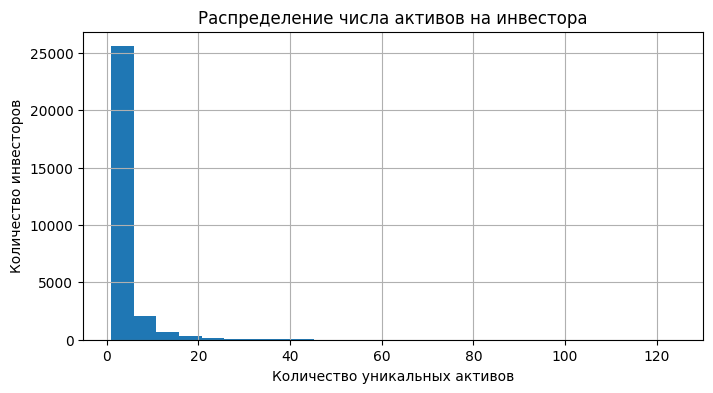

In [17]:
plt.figure(figsize=(8,4))
user_activity.hist(bins=25)
plt.xlabel("Количество уникальных активов")
plt.ylabel("Количество инвесторов")
plt.title("Распределение числа активов на инвестора")
plt.show()

In [18]:
item_activity = interaction_counts.groupby("ISIN")["customerID"].nunique()
item_activity.describe()

,customerID
count,320.00000
mean,280.88750
std,713.70883
min,1.00000
25%,6.00000
50%,58.50000
75%,194.50000
max,8162.00000


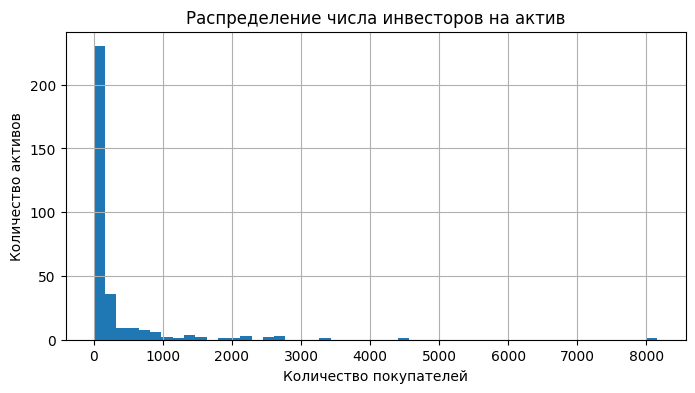

In [19]:
plt.figure(figsize=(8,4))
item_activity.hist(bins=50)

plt.xlabel("Количество покупателей")
plt.ylabel("Количество активов")
plt.title("Распределение числа инвесторов на актив")
plt.show()

In [20]:
interaction_counts["count"].describe()

,count
count,89884.000000
mean,2.546760
std,5.989658
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,512.000000


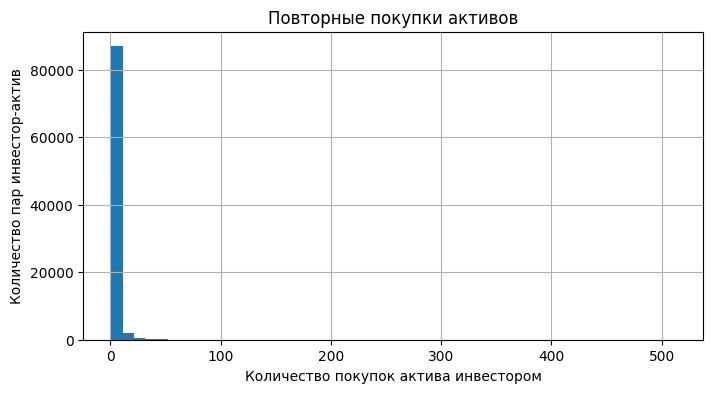

In [21]:
plt.figure(figsize=(8,4))
interaction_counts["count"].hist(bins=50)

plt.xlabel("Количество покупок актива инвестором")
plt.ylabel("Количество пар инвестор-актив")
plt.title("Повторные покупки активов")
plt.show()

In [22]:
n_users = interaction_counts["customerID"].nunique()
n_items = interaction_counts["ISIN"].nunique()
n_possible = n_users * n_items
n_observed = len(interaction_counts)
sparsity = 1 - n_observed / n_possible
print(f"Разреженность: {sparsity:.4%}")

Разреженность: 99.0344%


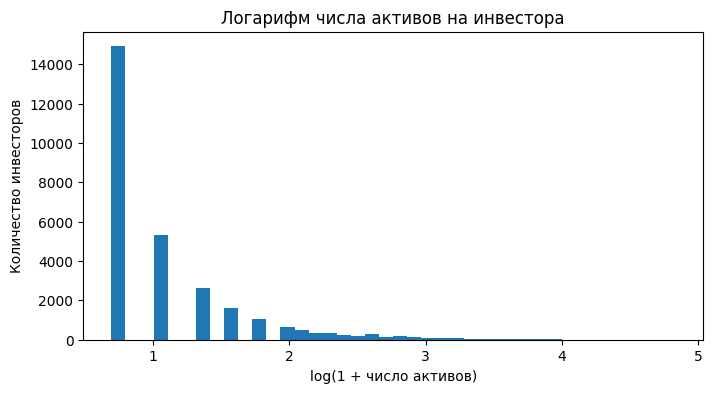

In [23]:
plt.figure(figsize=(8, 4))
plt.hist(np.log1p(user_activity), bins=40)
plt.title("Логарифм числа активов на инвестора")
plt.xlabel("log(1 + число активов)")
plt.ylabel("Количество инвесторов")
plt.show()

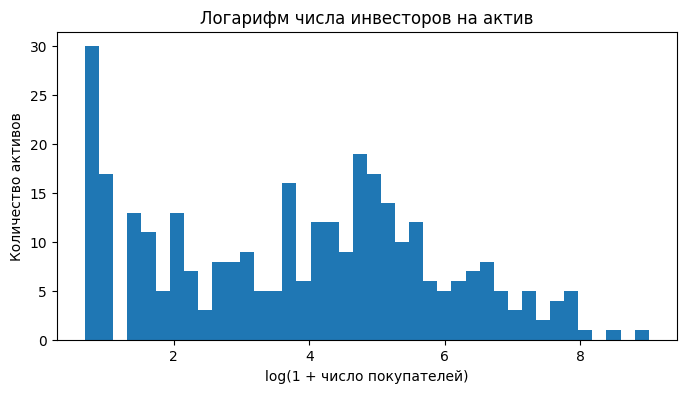

In [24]:
plt.figure(figsize=(8, 4))
plt.hist(np.log1p(item_activity), bins=40)
plt.title("Логарифм числа инвесторов на актив")
plt.xlabel("log(1 + число покупателей)")
plt.ylabel("Количество активов")
plt.show()

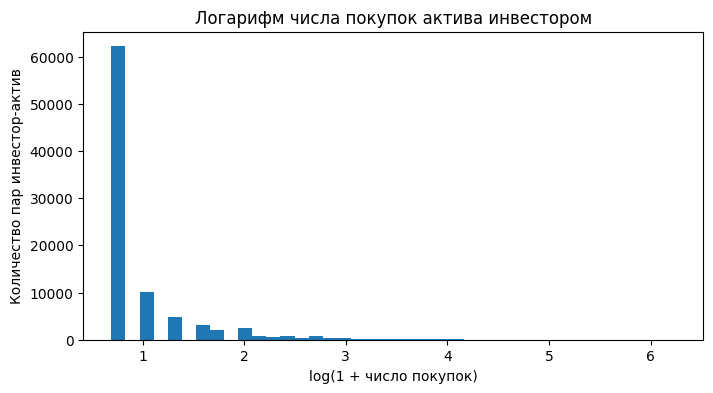

In [25]:
plt.figure(figsize=(8, 4))
plt.hist(np.log1p(interaction_counts["count"]), bins=40)
plt.title("Логарифм числа покупок актива инвестором")
plt.xlabel("log(1 + число покупок)")
plt.ylabel("Количество пар инвестор-актив")
plt.show()

## Подготовка данных, Time-aware Train / Valid / Test Split

In [26]:
transactions_for_split = buys.copy()

print("Размер:", transactions_for_split.shape)
print(transactions_for_split["timestamp"].min(), transactions_for_split["timestamp"].max())

Размер: (228913, 9)
2018-01-02 00:00:00 2022-11-30 00:00:00


In [27]:
monthly_counts = (
    transactions_for_split["timestamp"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)
monthly_counts

,count
timestamp,
2018-01,37474
2018-02,1283
2018-03,1372
2018-04,855
2018-05,1670
2018-06,862
2018-07,623
2018-08,870
2018-09,1548


In [28]:
train_transactions = transactions_for_split[transactions_for_split["timestamp"] < "2021-10-01"].copy()
valid_transactions = transactions_for_split[
    (transactions_for_split["timestamp"] >= "2021-10-01")
    & (transactions_for_split["timestamp"] < "2022-04-01")
].copy()
test_transactions = transactions_for_split[transactions_for_split["timestamp"] >= "2022-04-01"].copy()

print("Train:", train_transactions.shape)
print("Valid:", valid_transactions.shape)
print("Test :", test_transactions.shape)

Train: (172419, 9)
Valid: (30345, 9)
Test : (26149, 9)


In [29]:
print(train_transactions["timestamp"].min(), train_transactions["timestamp"].max())
print(valid_transactions["timestamp"].min(), valid_transactions["timestamp"].max())
print(test_transactions["timestamp"].min(), test_transactions["timestamp"].max())

2018-01-02 00:00:00 2021-09-30 00:00:00
2021-10-01 00:00:00 2022-03-31 00:00:00
2022-04-01 00:00:00 2022-11-30 00:00:00


In [30]:
def make_interactions(df):
    return df.groupby(["customerID", "ISIN"]).size().reset_index(name="count")

train_interactions_all = make_interactions(train_transactions)
valid_interactions_all = make_interactions(valid_transactions)
test_interactions_all = make_interactions(test_transactions)

print("Train interactions:", train_interactions_all.shape)
print("Valid interactions:", valid_interactions_all.shape)
print("Test interactions :", test_interactions_all.shape)

Train interactions: (75817, 3)
Valid interactions: (16441, 3)
Test interactions : (11655, 3)


In [31]:
threshold_results = []
user_activity_train = train_interactions_all.groupby("customerID")["ISIN"].nunique()
item_activity_train = train_interactions_all.groupby("ISIN")["customerID"].nunique()

for min_user_assets in [1, 2, 3, 4, 5]:
    for min_item_buyers in [1, 2, 3, 4, 5, 10]:
        users = user_activity_train[user_activity_train >= min_user_assets].index
        items = item_activity_train[item_activity_train >= min_item_buyers].index
        tmp = train_interactions_all[
            train_interactions_all["customerID"].isin(users)
            & train_interactions_all["ISIN"].isin(items)
        ]
        n_users = tmp["customerID"].nunique()
        n_items = tmp["ISIN"].nunique()
        n_interactions = len(tmp)
        sparsity = 1 - n_interactions / (n_users * n_items)
        threshold_results.append({
            "min_user_assets": min_user_assets,
            "min_item_buyers": min_item_buyers,
            "n_users": n_users,
            "n_items": n_items,
            "n_interactions": n_interactions,
            "sparsity": sparsity,
        })

threshold_results = pd.DataFrame(threshold_results)
threshold_results

,min_user_assets,min_item_buyers,n_users,n_items,n_interactions,sparsity
0,1,1,26703,294,75817,0.990343
1,1,2,26695,267,75790,0.989367
2,1,3,26686,255,75766,0.988866
3,1,4,26677,245,75736,0.988412
4,1,5,26665,236,75700,0.987971
5,1,10,26635,211,75532,0.986560
6,2,1,12306,279,61420,0.982111
7,2,2,12305,259,61400,0.980734
8,2,3,12305,251,61385,0.980125
9,2,4,12305,243,61364,0.979478


In [32]:
MIN_USER_ASSETS = 3
MIN_ITEM_BUYERS = 3

model_users = user_activity_train[user_activity_train >= MIN_USER_ASSETS].index
candidate_items = item_activity_train[item_activity_train >= MIN_ITEM_BUYERS].index
fallback_users = user_activity_train[user_activity_train < MIN_USER_ASSETS].index

print("Порог активов на пользователя:", MIN_USER_ASSETS)
print("Порог покупателей на актив:", MIN_ITEM_BUYERS)
print("\nModel users:", len(model_users))
print("Fallback users:", len(fallback_users))
print("Candidate items:", len(candidate_items))

Порог активов на пользователя: 3
Порог покупателей на актив: 3

Model users: 7350
Fallback users: 19353
Candidate items: 255


In [33]:
train_interactions = train_interactions_all[train_interactions_all["customerID"].isin(model_users)& train_interactions_all["ISIN"].isin(candidate_items)].copy()
valid_interactions = valid_interactions_all[valid_interactions_all["customerID"].isin(model_users) & valid_interactions_all["ISIN"].isin(candidate_items)].copy()
test_interactions = test_interactions_all[test_interactions_all["customerID"].isin(model_users) & test_interactions_all["ISIN"].isin(candidate_items)].copy()

print("Train interactions:", train_interactions.shape)
print("Valid interactions:", valid_interactions.shape)
print("Test interactions :", test_interactions.shape)

Train interactions: (51478, 3)
Valid interactions: (10295, 3)
Test interactions : (8261, 3)


In [34]:
print("Users in train:", train_interactions["customerID"].nunique())
print("Items in train:", train_interactions["ISIN"].nunique())
print("Users in valid:", valid_interactions["customerID"].nunique())
print("Items in valid:", valid_interactions["ISIN"].nunique())
print("Users in test:", test_interactions["customerID"].nunique())
print("Items in test:", test_interactions["ISIN"].nunique())

Users in train: 7349
Items in train: 250
Users in valid: 2665
Items in valid: 169
Users in test: 2290
Items in test: 155


In [35]:
final_users = np.sort(train_interactions["customerID"].unique())
final_items = np.sort(train_interactions["ISIN"].unique())
user_index = pd.Index(final_users, name="customerID")
item_index = pd.Index(final_items, name="ISIN")
print("Users:", len(user_index))
print("Items:", len(item_index))

Users: 7349
Items: 250


In [36]:
def build_interaction_matrix(interactions):
    matrix = interactions.pivot_table(index="customerID", columns="ISIN", values="count", fill_value=0).reindex(
            index=user_index,
            columns=item_index,
            fill_value=0
        )
    return matrix

train_matrix = build_interaction_matrix(train_interactions)
valid_matrix = build_interaction_matrix(valid_interactions)
test_matrix = build_interaction_matrix(test_interactions)

train_binary_matrix = (train_matrix > 0).astype(int)
valid_binary_matrix = (valid_matrix > 0).astype(int)
test_binary_matrix = (test_matrix > 0).astype(int)

In [37]:
print(train_binary_matrix.shape)
print(valid_binary_matrix.shape)
print(test_binary_matrix.shape)

print(train_binary_matrix.values.sum())
print(valid_binary_matrix.values.sum())
print(test_binary_matrix.values.sum())

(7349, 250)
(7349, 250)
(7349, 250)
51478
10295
8261


In [38]:
valid_users = valid_binary_matrix.sum(axis=1) > 0
test_users = test_binary_matrix.sum(axis=1) > 0

print("Пользователей с взаимодействиями в Valid:", valid_users.sum())
print("Пользователей с взаимодействиями в Test:", test_users.sum())
print("\nСтатистика valid-активов ")
print(valid_binary_matrix.loc[valid_users].sum(axis=1).describe())
print("\nСтатистика test-активов")
print(test_binary_matrix.loc[test_users].sum(axis=1).describe())

Пользователей с взаимодействиями в Valid: 2665
Пользователей с взаимодействиями в Test: 2290

Статистика valid-активов 
count    2665.000000
mean        3.863039
std         4.411501
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max        48.000000
dtype: float64

Статистика test-активов
count    2290.000000
mean        3.607424
std         4.399158
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        62.000000
dtype: float64


## Обогощение данных

In [39]:
train_end = train_transactions["timestamp"].max()
asset_features = (
    asset_information[asset_information["ISIN"].isin(final_items)][
        [
            "ISIN",
            "assetName",
            "assetCategory",
            "assetSubCategory",
            "marketID",
            "sector",
            "industry",
        ]
    ]
    .drop_duplicates("ISIN")
    .copy()
)
asset_features = asset_features.merge(markets[["marketID", "country", "marketClass"]], on="marketID", how="left")
asset_features = asset_features.rename(
    columns={
        "sector": "sector_far",
        "industry": "industry_far",
        "country": "marketCountry",
    }
)

print("Дата окончания train:", train_end.date())
print("Размер базовой таблицы активов:", asset_features.shape)
asset_features.head()

Дата окончания train: 2021-09-30
Размер базовой таблицы активов: (250, 9)


,ISIN,assetName,assetCategory,assetSubCategory,marketID,sector_far,industry_far,marketCountry,marketClass
0,GRF000011004,DHLOS PET OTE,MTF,Balanced,AEDAK,NaN,NaN,Greece,Public Securities
1,GRF000014008,DELOS FIXED INCOME PLUS - BOND FUND,MTF,Structured,AEDAK,NaN,NaN,Greece,Public Securities
2,GRF000022001,ΔΗΛΟΣ ΒΡΑΧΥΠΡΟΘΕΣΜΩΝ & ΜΕΣΟΠΡΟΘΕΣΜΩΝ ΕΠΕΝΔΥΣΕΩ...,MTF,Money Market,AEDAK,NaN,NaN,Greece,Public Securities
3,GRF000023009,DHLOS EISODHMATOS OMOLOGIAKO ESOTERIKOY,MTF,Bond,AEDAK,NaN,NaN,Greece,Public Securities
4,GRF000024007,DHLOS EUROBOND,MTF,Bond,AEDAK,NaN,NaN,Greece,Public Securities


In [40]:
price_data_train = close_prices[(close_prices["ISIN"].isin(final_items)) & (close_prices["timestamp"] <= train_end)].copy()
price_data_train = price_data_train.sort_values(["ISIN", "timestamp"])
price_data_train["daily_return"] = price_data_train.groupby("ISIN")["closePrice"].pct_change()
print("Размер price_data_train:", price_data_train.shape)
print("Период цен:")
print(price_data_train["timestamp"].min().date(), "-", price_data_train["timestamp"].max().date())
price_data_train.head()

Размер price_data_train: (207602, 4)
Период цен:
2018-01-02 - 2021-09-30


,ISIN,timestamp,closePrice,daily_return
0,100974271034,2018-01-02,3.33,NaN
1,100974271034,2018-01-03,3.33,0.000000
2,100974271034,2018-01-04,3.43,0.030030
3,100974271034,2018-01-05,3.48,0.014577
4,100974271034,2018-01-08,3.63,0.043103


In [41]:
def asset_price_features(group):
    group = group.sort_values("timestamp").copy()
    prices = group["closePrice"]
    returns = group["daily_return"]
    last_price = prices.iloc[-1]
    def period_return(n_days):
        if len(prices) > n_days:
            return last_price / prices.iloc[-n_days - 1] - 1
        return np.nan
    running_max = prices.cummax()
    drawdown = prices / running_max - 1
    return pd.Series({
        "return_30d": period_return(30),
        "return_90d": period_return(90),
        "return_180d": period_return(180),
        "volatility_30d": returns.tail(30).std(),
        "volatility_90d": returns.tail(90).std(),
        "max_drawdown_train": drawdown.min(),
        "last_price_train": last_price,
        "n_price_observations_train": len(prices),
    })

price_features_train = price_data_train.groupby("ISIN").apply(asset_price_features).reset_index()
price_features_train["sharpe_like_90d_train"] = price_features_train["return_90d"] / price_features_train["volatility_90d"]
print("Размер таблицы ценовых признаков:", price_features_train.shape)
price_features_train.head()

Размер таблицы ценовых признаков: (250, 10)


,ISIN,return_30d,return_90d,return_180d,volatility_30d,volatility_90d,max_drawdown_train,last_price_train,n_price_observations_train,sharpe_like_90d_train
0,100974271034,-0.036005,-0.120763,0.178977,0.022551,0.020287,-0.654545,4.150,975.0,-5.952601
1,BE0974271034,-0.035591,-0.086957,0.217391,0.032289,0.024639,-0.650000,4.200,975.0,-3.529187
2,BE0974303357,-0.008333,-0.084615,0.400000,0.020732,0.021387,-0.617021,2.380,975.0,-3.956345
3,CH0198251305,-0.100193,-0.061621,0.088155,0.013764,0.013082,-0.515816,28.020,975.0,-4.710463
4,CY0109232112,0.068376,0.029654,0.033058,0.021106,0.014794,-0.319625,0.125,262.0,2.004452


In [42]:
def asset_price_risk_features(group):
    group = group.sort_values("timestamp").copy()
    returns = group["daily_return"].dropna()

    def positive_return_share(n_days):
        recent_returns = returns.tail(n_days)
        if len(recent_returns) == 0:
            return np.nan
        return (recent_returns > 0).mean()

    def downside_volatility(n_days):
        recent_returns = returns.tail(n_days)
        negative_returns = recent_returns[recent_returns < 0]

        if len(negative_returns) <= 1:
            return np.nan

        return negative_returns.std()

    return pd.Series({
        "positive_return_share_30d": positive_return_share(30),
        "positive_return_share_90d": positive_return_share(90),
        "downside_volatility_30d": downside_volatility(30),
        "downside_volatility_90d": downside_volatility(90),
    })


price_risk_features_train = (
    price_data_train
    .groupby("ISIN")
    .apply(asset_price_risk_features)
    .reset_index()
)

print("Размер таблицы риск-признаков:", price_risk_features_train.shape)
price_risk_features_train.head()

Размер таблицы риск-признаков: (250, 5)


,ISIN,positive_return_share_30d,positive_return_share_90d,downside_volatility_30d,downside_volatility_90d
0,100974271034,0.466667,0.466667,0.012251,0.014544
1,BE0974271034,0.433333,0.444444,0.016477,0.015770
2,BE0974303357,0.433333,0.444444,0.015820,0.015623
3,CH0198251305,0.333333,0.444444,0.009607,0.009276
4,CY0109232112,0.366667,0.355556,0.010383,0.007597


In [43]:
asset_features_base = asset_information[asset_information["ISIN"].isin(final_items)].copy()
asset_features_base = asset_features_base.rename(
    columns={
        "country": "marketCountry",
        "sector": "sector_far",
        "industry": "industry_far",
    }
)
print("Размер базовой таблицы активов:", asset_features_base.shape)
asset_features_base.head()

Размер базовой таблицы активов: (264, 9)


,ISIN,assetName,assetShortName,assetCategory,assetSubCategory,marketID,sector_far,industry_far,timestamp
0,GRF000011004,DHLOS PET OTE,DELPOIB,MTF,Balanced,AEDAK,NaN,NaN,2018-01-02
1,GRF000014008,DELOS FIXED INCOME PLUS - BOND FUND,DELDBDF,MTF,Structured,AEDAK,NaN,NaN,2018-01-02
2,GRF000022001,ΔΗΛΟΣ ΒΡΑΧΥΠΡΟΘΕΣΜΩΝ & ΜΕΣΟΠΡΟΘΕΣΜΩΝ ΕΠΕΝΔΥΣΕΩ...,DELPIMM,MTF,Money Market,AEDAK,NaN,NaN,2018-01-02
3,GRF000023009,DHLOS EISODHMATOS OMOLOGIAKO ESOTERIKOY,DELFXIB,MTF,Bond,AEDAK,NaN,NaN,2018-01-02
4,GRF000024007,DHLOS EUROBOND,DELEURB,MTF,Bond,AEDAK,NaN,NaN,2018-01-02


In [44]:
asset_information[asset_information["ISIN"].isin(final_items)]["ISIN"].value_counts().head(20)

,count
ISIN,
GRS498003003,3
GRC8161185B1,3
GRC1451184D4,2
GRC1441197B3,2
GRC4261213D5,2
GRC5211214B5,2
GRC5091217D9,2
GRC4951193D4,2
GRC813119AD1,2


In [45]:
asset_features_base = asset_information[asset_information["ISIN"].isin(final_items)].copy()
asset_features_base["timestamp"] = pd.to_datetime(asset_features_base["timestamp"])
asset_features_base = (asset_features_base[asset_features_base["timestamp"] <= train_end].sort_values(["ISIN", "timestamp"]).groupby("ISIN").tail(1).reset_index(drop=True))

print(asset_features_base.shape)
print(asset_features_base["ISIN"].nunique())

(250, 9)
250


In [46]:
asset_features_train = asset_features_base.merge(price_features_train, on="ISIN", how="left")
asset_features_train = asset_features_train.merge(price_risk_features_train, on="ISIN", how="left")
print("Размер таблицы активов:", asset_features_train.shape)
asset_features_train.head()

Размер таблицы активов: (250, 22)


,ISIN,assetName,assetShortName,assetCategory,assetSubCategory,marketID,sector,industry,timestamp,return_30d,return_90d,return_180d,volatility_30d,volatility_90d,max_drawdown_train,last_price_train,n_price_observations_train,sharpe_like_90d_train,positive_return_share_30d,positive_return_share_90d,downside_volatility_30d,downside_volatility_90d
0,100974271034,VIOHALCO SA (el-GR),ΒΙΟ,Stock,Large Cap,XATH,NaN,NaN,2018-01-02,-0.036005,-0.120763,0.178977,0.022551,0.020287,-0.654545,4.150,975.0,-5.952601,0.466667,0.466667,0.012251,0.014544
1,BE0974271034,VIOHALCO SA,VIO,Stock,NaN,ALXB,Industrials,Metal Fabrication,2018-01-02,-0.035591,-0.086957,0.217391,0.032289,0.024639,-0.650000,4.200,975.0,-3.529187,0.433333,0.444444,0.016477,0.015770
2,BE0974303357,CENERGY HOLDINGS SA,CENER,Stock,NaN,XATH,Industrials,Electrical Equipment & Parts,2018-01-02,-0.008333,-0.084615,0.400000,0.020732,0.021387,-0.617021,2.380,975.0,-3.956345,0.433333,0.444444,0.015820,0.015623
3,CH0198251305,COCA COLA HELLENIC BOTTLING CO AG,ΕΕΕ,Stock,Large Cap,XATH,Consumer Defensive,Beverages - Non-Alcoholic,2018-01-02,-0.100193,-0.061621,0.088155,0.013764,0.013082,-0.515816,28.020,975.0,-4.710463,0.333333,0.444444,0.009607,0.009276
4,CY0109232112,CAIRO MEZZ PLC,ΚΑΙΡΟΜΕΖ,Stock,NaN,ENAX,Financial Services,Capital Markets,2020-09-29,0.068376,0.029654,0.033058,0.021106,0.014794,-0.319625,0.125,262.0,2.004452,0.366667,0.355556,0.010383,0.007597


In [47]:
asset_features_train[["positive_return_share_30d", "positive_return_share_90d", "downside_volatility_30d", "downside_volatility_90d"]].describe()

,positive_return_share_30d,positive_return_share_90d,downside_volatility_30d,downside_volatility_90d
count,250.000000,250.000000,216.000000,234.000000
mean,0.309733,0.338929,0.013143,0.016762
std,0.174957,0.181513,0.013206,0.017943
min,0.000000,0.000000,0.000000,0.000000
25%,0.166667,0.186111,0.005186,0.006944
50%,0.350000,0.388889,0.010067,0.012716
75%,0.433333,0.466667,0.016033,0.019881
max,0.666667,0.644444,0.082151,0.119645


In [48]:
asset_features_train.isna().sum().sort_values(ascending=False)

,0
assetSubCategory,170
industry,81
sector,73
downside_volatility_30d,34
sharpe_like_90d_train,17
downside_volatility_90d,16
return_180d,8
return_90d,3
marketID,0
assetName,0


In [49]:
numeric_asset_features = [
    "return_30d",
    "return_90d",
    "return_180d",
    "volatility_30d",
    "volatility_90d",
    "max_drawdown_train",
    "last_price_train",
    "n_price_observations_train",
    "sharpe_like_90d_train",
    "positive_return_share_30d",
    "positive_return_share_90d",
    "downside_volatility_30d",
    "downside_volatility_90d",
]

asset_features_train[numeric_asset_features].describe()

,return_30d,return_90d,return_180d,volatility_30d,volatility_90d,max_drawdown_train,last_price_train,n_price_observations_train,sharpe_like_90d_train,positive_return_share_30d,positive_return_share_90d,downside_volatility_30d,downside_volatility_90d
count,250.000000,247.000000,242.000000,250.000000,250.000000,250.000000,250.000000,250.000000,233.000000,250.000000,250.000000,216.000000,234.000000
mean,0.012623,0.092568,0.219382,0.018937,0.020353,-0.448917,54.388503,830.408000,0.517816,0.309733,0.338929,0.013143,0.016762
std,0.151789,0.297350,0.398466,0.020132,0.017246,0.230737,258.829686,251.416552,18.245594,0.174957,0.181513,0.013206,0.017943
min,-0.596128,-0.640736,-0.916925,0.000000,0.000000,-0.978846,0.012500,36.000000,-175.132614,0.000000,0.000000,0.000000,0.000000
25%,-0.032258,-0.022721,-0.001460,0.003116,0.004687,-0.613984,0.705000,693.500000,-2.753309,0.166667,0.186111,0.005186,0.006944
50%,-0.000775,0.000000,0.094193,0.016153,0.018124,-0.459878,2.472100,975.000000,0.484751,0.350000,0.388889,0.010067,0.012716
75%,0.019942,0.110526,0.304551,0.027966,0.030945,-0.298052,11.463150,975.000000,6.515546,0.433333,0.466667,0.016033,0.019881
max,1.116438,2.328767,2.444444,0.184173,0.109727,-0.013776,3009.100000,975.000000,48.029135,0.666667,0.644444,0.082151,0.119645


In [50]:
asset_features_train = asset_features_train.rename(columns={"sector": "sector_far", "industry": "industry_far",})
asset_features_train = asset_features_train.merge(markets[["marketID", "country", "marketClass"]], on="marketID", how="left")
asset_features_train = asset_features_train.rename(columns={"country": "marketCountry"})
print("Размер таблицы активов:", asset_features_train.shape)
asset_features_train.columns.tolist()
asset_features_train.head()

Размер таблицы активов: (250, 24)


,ISIN,assetName,assetShortName,assetCategory,assetSubCategory,marketID,sector_far,industry_far,timestamp,return_30d,return_90d,return_180d,volatility_30d,volatility_90d,max_drawdown_train,last_price_train,n_price_observations_train,sharpe_like_90d_train,positive_return_share_30d,positive_return_share_90d,downside_volatility_30d,downside_volatility_90d,marketCountry,marketClass
0,100974271034,VIOHALCO SA (el-GR),ΒΙΟ,Stock,Large Cap,XATH,NaN,NaN,2018-01-02,-0.036005,-0.120763,0.178977,0.022551,0.020287,-0.654545,4.150,975.0,-5.952601,0.466667,0.466667,0.012251,0.014544,Greece,Public Securities
1,BE0974271034,VIOHALCO SA,VIO,Stock,NaN,ALXB,Industrials,Metal Fabrication,2018-01-02,-0.035591,-0.086957,0.217391,0.032289,0.024639,-0.650000,4.200,975.0,-3.529187,0.433333,0.444444,0.016477,0.015770,Belgium,Public Securities
2,BE0974303357,CENERGY HOLDINGS SA,CENER,Stock,NaN,XATH,Industrials,Electrical Equipment & Parts,2018-01-02,-0.008333,-0.084615,0.400000,0.020732,0.021387,-0.617021,2.380,975.0,-3.956345,0.433333,0.444444,0.015820,0.015623,Greece,Public Securities
3,CH0198251305,COCA COLA HELLENIC BOTTLING CO AG,ΕΕΕ,Stock,Large Cap,XATH,Consumer Defensive,Beverages - Non-Alcoholic,2018-01-02,-0.100193,-0.061621,0.088155,0.013764,0.013082,-0.515816,28.020,975.0,-4.710463,0.333333,0.444444,0.009607,0.009276,Greece,Public Securities
4,CY0109232112,CAIRO MEZZ PLC,ΚΑΙΡΟΜΕΖ,Stock,NaN,ENAX,Financial Services,Capital Markets,2020-09-29,0.068376,0.029654,0.033058,0.021106,0.014794,-0.319625,0.125,262.0,2.004452,0.366667,0.355556,0.010383,0.007597,Greece,Public Securities


In [51]:
asset_features_train.columns.tolist()

['ISIN',
 'assetName',
 'assetShortName',
 'assetCategory',
 'assetSubCategory',
 'marketID',
 'sector_far',
 'industry_far',
 'timestamp',
 'return_30d',
 'return_90d',
 'return_180d',
 'volatility_30d',
 'volatility_90d',
 'max_drawdown_train',
 'last_price_train',
 'n_price_observations_train',
 'sharpe_like_90d_train',
 'positive_return_share_30d',
 'positive_return_share_90d',
 'downside_volatility_30d',
 'downside_volatility_90d',
 'marketCountry',
 'marketClass']

In [52]:
asset_features_train = asset_features_train.loc[:, ~asset_features_train.columns.duplicated()].copy()
asset_features_train = asset_features_train.rename(columns={"marketClass_x": "marketClass"})
asset_features_train = asset_features_train.drop(columns=["marketClass_y"],errors="ignore")
print(asset_features_train.shape)
asset_features_train.columns.tolist()

(250, 24)


['ISIN',
 'assetName',
 'assetShortName',
 'assetCategory',
 'assetSubCategory',
 'marketID',
 'sector_far',
 'industry_far',
 'timestamp',
 'return_30d',
 'return_90d',
 'return_180d',
 'volatility_30d',
 'volatility_90d',
 'max_drawdown_train',
 'last_price_train',
 'n_price_observations_train',
 'sharpe_like_90d_train',
 'positive_return_share_30d',
 'positive_return_share_90d',
 'downside_volatility_30d',
 'downside_volatility_90d',
 'marketCountry',
 'marketClass']

In [53]:
print(asset_features_train.shape)
print("\nПропуски:")
print(asset_features_train.isna().sum().sort_values(ascending=False))
print("\nКатегориальные признаки:")
display(asset_features_train[
    [
        "assetCategory",
        "assetSubCategory",
        "marketID",
        "sector_far",
        "industry_far",
        "marketCountry",
        "marketClass",
    ]
].head())
print("\nЧисловые признаки:")
display(
    asset_features_train[
        [
            "return_30d",
            "return_90d",
            "return_180d",
            "volatility_30d",
            "volatility_90d",
            "max_drawdown_train",
            "last_price_train",
            "n_price_observations_train",
            "sharpe_like_90d_train",
            "positive_return_share_30d",
            "positive_return_share_90d",
            "downside_volatility_30d",
            "downside_volatility_90d",
        ]
    ].describe()
)

(250, 24)

Пропуски:
assetSubCategory              170
industry_far                   81
sector_far                     73
downside_volatility_30d        34
sharpe_like_90d_train          17
downside_volatility_90d        16
return_180d                     8
return_90d                      3
marketID                        0
assetName                       0
assetShortName                  0
assetCategory                   0
ISIN                            0
volatility_30d                  0
return_30d                      0
timestamp                       0
last_price_train                0
max_drawdown_train              0
volatility_90d                  0
n_price_observations_train      0
positive_return_share_90d       0
positive_return_share_30d       0
marketCountry                   0
marketClass                     0
dtype: int64

Категориальные признаки:


,assetCategory,assetSubCategory,marketID,sector_far,industry_far,marketCountry,marketClass
0,Stock,Large Cap,XATH,NaN,NaN,Greece,Public Securities
1,Stock,NaN,ALXB,Industrials,Metal Fabrication,Belgium,Public Securities
2,Stock,NaN,XATH,Industrials,Electrical Equipment & Parts,Greece,Public Securities
3,Stock,Large Cap,XATH,Consumer Defensive,Beverages - Non-Alcoholic,Greece,Public Securities
4,Stock,NaN,ENAX,Financial Services,Capital Markets,Greece,Public Securities



Числовые признаки:


,return_30d,return_90d,return_180d,volatility_30d,volatility_90d,max_drawdown_train,last_price_train,n_price_observations_train,sharpe_like_90d_train,positive_return_share_30d,positive_return_share_90d,downside_volatility_30d,downside_volatility_90d
count,250.000000,247.000000,242.000000,250.000000,250.000000,250.000000,250.000000,250.000000,233.000000,250.000000,250.000000,216.000000,234.000000
mean,0.012623,0.092568,0.219382,0.018937,0.020353,-0.448917,54.388503,830.408000,0.517816,0.309733,0.338929,0.013143,0.016762
std,0.151789,0.297350,0.398466,0.020132,0.017246,0.230737,258.829686,251.416552,18.245594,0.174957,0.181513,0.013206,0.017943
min,-0.596128,-0.640736,-0.916925,0.000000,0.000000,-0.978846,0.012500,36.000000,-175.132614,0.000000,0.000000,0.000000,0.000000
25%,-0.032258,-0.022721,-0.001460,0.003116,0.004687,-0.613984,0.705000,693.500000,-2.753309,0.166667,0.186111,0.005186,0.006944
50%,-0.000775,0.000000,0.094193,0.016153,0.018124,-0.459878,2.472100,975.000000,0.484751,0.350000,0.388889,0.010067,0.012716
75%,0.019942,0.110526,0.304551,0.027966,0.030945,-0.298052,11.463150,975.000000,6.515546,0.433333,0.466667,0.016033,0.019881
max,1.116438,2.328767,2.444444,0.184173,0.109727,-0.013776,3009.100000,975.000000,48.029135,0.666667,0.644444,0.082151,0.119645


## Yfinance

In [54]:
def find_yahoo_ticker_by_isin(isin):
    try:
        search = yf.Search(isin, max_results=5)
        quotes = search.quotes
        if len(quotes) == 0:
            return None
        return quotes[0].get("symbol")
    except Exception:
        return None

final_isins = asset_features_train["ISIN"].unique()
isin_to_ticker = {}
for isin in tqdm(final_isins):
    isin_to_ticker[isin] = find_yahoo_ticker_by_isin(isin)
ticker_map_train = pd.DataFrame({
    "ISIN": list(isin_to_ticker.keys()),
    "yahoo_ticker": list(isin_to_ticker.values())
})
ticker_map_train["found"] = ticker_map_train["yahoo_ticker"].notna()
print("Всего активов:", len(ticker_map_train))
print("Найдено тикеров:", ticker_map_train["found"].sum())
print("Доля покрытия:", round(ticker_map_train["found"].mean(), 3))
ticker_map_train.head()

100%|██████████| 250/250 [00:41<00:00,  6.02it/s]

Всего активов: 250
Найдено тикеров: 133
Доля покрытия: 0.532


,ISIN,yahoo_ticker,found
0,100974271034,None,False
1,BE0974271034,VIO.BR,True
2,BE0974303357,CENER.BR,True
3,CH0198251305,CCH.L,True
4,CY0109232112,CAIROMEZ.AT,True


In [55]:
yf_static_fields = [
    "symbol",
    "quoteType",
    "shortName",
    "longName",
    "sector",
    "industry",
    "country",
    "currency",
]
def get_yfinance_static_info(ticker):
    try:
        info = yf.Ticker(ticker).info
        return {field: info.get(field) for field in yf_static_fields}
    except Exception:
        return {field: None for field in yf_static_fields}
found_tickers = (ticker_map_train.loc[ticker_map_train["found"], "yahoo_ticker"].dropna().unique())
print("Уникальных найденных тикеров:", len(found_tickers))
yf_rows = []
for ticker in tqdm(found_tickers):
    row = get_yfinance_static_info(ticker)
    row["yahoo_ticker"] = ticker
    yf_rows.append(row)
yf_static_features = pd.DataFrame(yf_rows)
print("Размер таблицы Yahoo static features:", yf_static_features.shape)
yf_static_features.head()

Уникальных найденных тикеров: 129


100%|██████████| 129/129 [00:27<00:00,  4.71it/s]

Размер таблицы Yahoo static features: (129, 9)


,symbol,quoteType,shortName,longName,sector,industry,country,currency,yahoo_ticker
0,VIO.BR,EQUITY,VIOHALCO,Viohalco S.A.,Industrials,Metal Fabrication,Belgium,EUR,VIO.BR
1,CENER.BR,EQUITY,CENERGY,Cenergy Holdings SA,Industrials,Electrical Equipment & Parts,Belgium,EUR,CENER.BR
2,CCH.L,EQUITY,COCA-COLA HBC AG ORD CHF6.70 (C,Coca-Cola HBC AG,Consumer Defensive,Beverages - Non-Alcoholic,Switzerland,GBp,CCH.L
3,CAIROMEZ.AT,EQUITY,CAIRO MEZZ PLC,Cairo Mezz Plc,Financial Services,Capital Markets,Cyprus,EUR,CAIROMEZ.AT
4,PVMEZZ.AT,EQUITY,PHOENIX VEGA MEZZ PLC,Phoenix Vega Mezz Plc,Financial Services,Asset Management,Cyprus,EUR,PVMEZZ.AT


In [56]:
ticker_map_train[ticker_map_train["found"]]["yahoo_ticker"].value_counts().head(20)

,count
yahoo_ticker,
MOYZK.AT,2
LEBEP.AT,2
KARE.AT,2
LEBEK.AT,2
VIO.BR,1
AETF.AT,1
CENER.BR,1
CAIROMEZ.AT,1
CCH.L,1


In [57]:
duplicate_tickers = (ticker_map_train[ticker_map_train["found"]]["yahoo_ticker"].value_counts())
duplicate_tickers = duplicate_tickers[duplicate_tickers > 1]
duplicate_tickers

,count
yahoo_ticker,
MOYZK.AT,2
LEBEP.AT,2
KARE.AT,2
LEBEK.AT,2


In [58]:
ticker_map_train[ticker_map_train["yahoo_ticker"].isin(duplicate_tickers.index)].sort_values("yahoo_ticker")

,ISIN,yahoo_ticker,found
82,GRS120003009,KARE.AT,True
83,GRS120131008,KARE.AT,True
69,GRS090003005,LEBEK.AT,True
71,GRS090101007,LEBEK.AT,True
70,GRS090004003,LEBEP.AT,True
72,GRS090106006,LEBEP.AT,True
56,GRS054003009,MOYZK.AT,True
57,GRS054061007,MOYZK.AT,True


In [59]:
yf_asset_features = ticker_map_train.merge(yf_static_features, on="yahoo_ticker", how="left")
asset_features_train = asset_features_train.merge(yf_asset_features, on="ISIN", how="left")
asset_features_train = asset_features_train.rename(columns={"sector": "sector_yf", "industry": "industry_yf", "country": "country_yf"})
print("Размер итоговой таблицы активов:", asset_features_train.shape)
asset_features_train.head()

Размер итоговой таблицы активов: (250, 34)


,ISIN,assetName,assetShortName,assetCategory,assetSubCategory,marketID,sector_far,industry_far,timestamp,return_30d,return_90d,return_180d,volatility_30d,volatility_90d,max_drawdown_train,last_price_train,n_price_observations_train,sharpe_like_90d_train,positive_return_share_30d,positive_return_share_90d,downside_volatility_30d,downside_volatility_90d,marketCountry,marketClass,yahoo_ticker,found,symbol,quoteType,shortName,longName,sector_yf,industry_yf,country_yf,currency
0,100974271034,VIOHALCO SA (el-GR),ΒΙΟ,Stock,Large Cap,XATH,NaN,NaN,2018-01-02,-0.036005,-0.120763,0.178977,0.022551,0.020287,-0.654545,4.150,975.0,-5.952601,0.466667,0.466667,0.012251,0.014544,Greece,Public Securities,None,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BE0974271034,VIOHALCO SA,VIO,Stock,NaN,ALXB,Industrials,Metal Fabrication,2018-01-02,-0.035591,-0.086957,0.217391,0.032289,0.024639,-0.650000,4.200,975.0,-3.529187,0.433333,0.444444,0.016477,0.015770,Belgium,Public Securities,VIO.BR,True,VIO.BR,EQUITY,VIOHALCO,Viohalco S.A.,Industrials,Metal Fabrication,Belgium,EUR
2,BE0974303357,CENERGY HOLDINGS SA,CENER,Stock,NaN,XATH,Industrials,Electrical Equipment & Parts,2018-01-02,-0.008333,-0.084615,0.400000,0.020732,0.021387,-0.617021,2.380,975.0,-3.956345,0.433333,0.444444,0.015820,0.015623,Greece,Public Securities,CENER.BR,True,CENER.BR,EQUITY,CENERGY,Cenergy Holdings SA,Industrials,Electrical Equipment & Parts,Belgium,EUR
3,CH0198251305,COCA COLA HELLENIC BOTTLING CO AG,ΕΕΕ,Stock,Large Cap,XATH,Consumer Defensive,Beverages - Non-Alcoholic,2018-01-02,-0.100193,-0.061621,0.088155,0.013764,0.013082,-0.515816,28.020,975.0,-4.710463,0.333333,0.444444,0.009607,0.009276,Greece,Public Securities,CCH.L,True,CCH.L,EQUITY,COCA-COLA HBC AG ORD CHF6.70 (C,Coca-Cola HBC AG,Consumer Defensive,Beverages - Non-Alcoholic,Switzerland,GBp
4,CY0109232112,CAIRO MEZZ PLC,ΚΑΙΡΟΜΕΖ,Stock,NaN,ENAX,Financial Services,Capital Markets,2020-09-29,0.068376,0.029654,0.033058,0.021106,0.014794,-0.319625,0.125,262.0,2.004452,0.366667,0.355556,0.010383,0.007597,Greece,Public Securities,CAIROMEZ.AT,True,CAIROMEZ.AT,EQUITY,CAIRO MEZZ PLC,Cairo Mezz Plc,Financial Services,Capital Markets,Cyprus,EUR


In [60]:
yahoo_columns = [
    "yahoo_ticker",
    "quoteType",
    "shortName",
    "longName",
    "sector_yf",
    "industry_yf",
    "country_yf",
    "currency",
]
asset_features_train[yahoo_columns].isna().sum().sort_values(ascending=False)

,0
industry_yf,131
country_yf,131
sector_yf,131
longName,119
shortName,117
quoteType,117
yahoo_ticker,117
currency,117


In [61]:
asset_features_train[yahoo_columns].notna().mean().sort_values(ascending=False)

,0
yahoo_ticker,0.532
quoteType,0.532
shortName,0.532
currency,0.532
longName,0.524
sector_yf,0.476
industry_yf,0.476
country_yf,0.476


In [62]:
asset_features_train["sector_final"] = (asset_features_train["sector_far"].fillna(asset_features_train["sector_yf"]))
asset_features_train["industry_final"] = (asset_features_train["industry_far"].fillna(asset_features_train["industry_yf"]))
asset_features_train["country_final"] = (asset_features_train["marketCountry"].fillna(asset_features_train["country_yf"]))

In [63]:
asset_features_train[["sector_final", "industry_final", "country_final"]].isna().sum()

,0
sector_final,65
industry_final,73
country_final,0


In [64]:
categorical_asset_features = [
    "assetCategory",
    "assetSubCategory",
    "marketID",
    "marketClass",
    "quoteType",
    "currency",
    "sector_final",
    "industry_final",
    "country_final",
]
numeric_asset_features = [
    "return_30d",
    "return_90d",
    "return_180d",
    "volatility_30d",
    "volatility_90d",
    "max_drawdown_train",
    "last_price_train",
    "n_price_observations_train",
    "sharpe_like_90d_train",
]
print("Категориальных признаков:", len(categorical_asset_features))
print("Числовых признаков:", len(numeric_asset_features))
asset_features_train[categorical_asset_features + numeric_asset_features].isna().sum().sort_values(ascending=False)

Категориальных признаков: 9
Числовых признаков: 9


,0
assetSubCategory,170
currency,117
quoteType,117
industry_final,73
sector_final,65
sharpe_like_90d_train,17
return_180d,8
return_90d,3
assetCategory,0
marketID,0


## Формирование признаков инвесторов


In [65]:
print("Количество записей:", len(customer_information))
print("Уникальных инвесторов:", customer_information["customerID"].nunique())
print("\nТипы клиентов:")
print(customer_information["customerType"].value_counts())
print("\nРиск-профили:")
print(customer_information["riskLevel"].value_counts())
print("\nИнвестиционная емкость:")
print(customer_information["investmentCapacity"].value_counts())

Количество записей: 32468
Уникальных инвесторов: 29090

Типы клиентов:
customerType
Mass            19810
Premium         10321
Professional     2046
Inactive          211
Legal Entity       80
Name: count, dtype: int64

Риск-профили:
riskLevel
Income                    10048
Balanced                   8684
Aggressive                 3202
Conservative               2916
Predicted_Conservative     2842
Predicted_Income           2704
Predicted_Balanced         1430
Not_Available               344
Predicted_Aggressive        298
Name: count, dtype: int64

Инвестиционная емкость:
investmentCapacity
CAP_LT30K                 14030
CAP_30K_80K                5529
Predicted_CAP_LT30K        5449
CAP_80K_300K               4220
Predicted_CAP_80K_300K     1025
Predicted_CAP_30K_80K       965
CAP_GT300K                  888
Not_Available               347
Predicted_CAP_GT300K         15
Name: count, dtype: int64


In [66]:
customer_information.dtypes

,0
customerID,object
customerType,object
riskLevel,object
investmentCapacity,object
lastQuestionnaireDate,datetime64[ns]
timestamp,datetime64[ns]


In [67]:
customer_train = customer_information.copy()
customer_train = customer_train[customer_train["timestamp"] <= train_end].copy()
print("Записей до конца train:", len(customer_train))
print("Уникальных инвесторов:", customer_train["customerID"].nunique())

customer_train = customer_train.sort_values(["customerID", "timestamp"]).groupby("customerID").tail(1).reset_index(drop=True)
print("После выбора последней записи:")
print("Строк:", len(customer_train))
print("Уникальных инвесторов:", customer_train["customerID"].nunique())

user_features_train = customer_train[customer_train["customerID"].isin(final_users)].copy()
print("Размер таблицы признаков инвесторов:", user_features_train.shape)
print("Уникальных инвесторов:", user_features_train["customerID"].nunique())

Записей до конца train: 27494
Уникальных инвесторов: 25475
После выбора последней записи:
Строк: 25475
Уникальных инвесторов: 25475
Размер таблицы признаков инвесторов: (7349, 6)
Уникальных инвесторов: 7349


In [68]:
user_train_stats = train_interactions.groupby("customerID").agg(user_n_assets_train=("ISIN", "nunique"), user_total_interactions_train=("count", "sum")).reset_index()
user_train_stats["user_avg_interactions_per_asset_train"] = user_train_stats["user_total_interactions_train"] / user_train_stats["user_n_assets_train"]
asset_popularity_train = train_interactions.groupby("ISIN")["customerID"].nunique().rename("asset_n_buyers_train").reset_index()
user_asset_popularity = train_interactions.merge(asset_popularity_train, on="ISIN", how="left")
user_popularity_stats = user_asset_popularity.groupby("customerID").agg(user_avg_asset_popularity_train=("asset_n_buyers_train", "mean"), user_max_asset_popularity_train=("asset_n_buyers_train", "max")).reset_index()
user_features_train = user_features_train.merge(user_train_stats, on="customerID", how="left")
user_features_train = user_features_train.merge(user_popularity_stats, on="customerID", how="left")
print("Размер таблицы признаков инвесторов:", user_features_train.shape)
user_features_train.head()

Размер таблицы признаков инвесторов: (7349, 11)


,customerID,customerType,riskLevel,investmentCapacity,lastQuestionnaireDate,timestamp,user_n_assets_train,user_total_interactions_train,user_avg_interactions_per_asset_train,user_avg_asset_popularity_train,user_max_asset_popularity_train
0,00017496858921195E5A,Professional,Aggressive,CAP_GT300K,2020-03-13,2021-03-19,7,30,4.285714,544.714286,1764
1,0004718496C71D464F57,Mass,Predicted_Conservative,Predicted_CAP_80K_300K,2000-01-01,2018-01-02,11,16,1.454545,1592.636364,3751
2,001270E70A4ECA1CD664,Mass,Balanced,CAP_LT30K,2018-05-24,2018-01-02,3,7,2.333333,1382.666667,1764
3,001387DFC77BD44899B2,Premium,Balanced,CAP_30K_80K,2018-10-09,2020-03-18,5,5,1.000000,1984.400000,3751
4,001A82FE1591AD3926C7,Premium,Income,CAP_30K_80K,2021-05-14,2018-01-02,3,3,1.000000,3038.666667,3751


In [69]:
user_features_train.isna().sum().sort_values(ascending=False)

,0
customerID,0
customerType,0
riskLevel,0
investmentCapacity,0
lastQuestionnaireDate,0
timestamp,0
user_n_assets_train,0
user_total_interactions_train,0
user_avg_interactions_per_asset_train,0
user_avg_asset_popularity_train,0


In [70]:
user_features_train["is_predicted_profile"] = (user_features_train["riskLevel"].str.startswith("Predicted")).astype(int)
user_features_train["is_predicted_capacity"] = (user_features_train["investmentCapacity"].str.startswith("Predicted")).astype(int)
user_features_train["has_questionnaire"] = (user_features_train["lastQuestionnaireDate"] != pd.Timestamp("2000-01-01")).astype(int)
user_features_train[["is_predicted_profile", "is_predicted_capacity", "has_questionnaire",]].mean()

,0
is_predicted_profile,0.126956
is_predicted_capacity,0.129269
has_questionnaire,0.873044


In [71]:
user_features_train["questionnaire_age_days"] = (train_end - user_features_train["lastQuestionnaireDate"]).dt.days
user_features_train.loc[user_features_train["has_questionnaire"] == 0, "questionnaire_age_days"] = np.nan
user_features_train["questionnaire_age_days"].describe()

,questionnaire_age_days
count,6416.000000
mean,676.866116
std,513.245602
min,-413.000000
25%,232.000000
50%,713.000000
75%,1140.000000
max,3136.000000


In [72]:
user_features_train["questionnaire_age_days"].isna().sum()

np.int64(933)

In [73]:
user_features_train[user_features_train["questionnaire_age_days"] < 0][["customerID", "timestamp", "lastQuestionnaireDate", "questionnaire_age_days"]].head(20)

,customerID,timestamp,lastQuestionnaireDate,questionnaire_age_days
8,003E7F47F258AAD9B6B2,2018-01-02,2022-08-04,-308.0
9,003F1A4138030CF429A4,2018-01-02,2022-04-28,-210.0
11,0059B0203C883553A892,2018-01-02,2021-11-04,-35.0
23,00A81AF0E919436934D5,2018-01-02,2022-09-26,-361.0
29,00EACFE08E276F6E5574,2020-01-16,2021-11-12,-43.0
30,00ECE569D99A346074C8,2018-01-02,2022-01-20,-112.0
46,017B3233D02BD4289928,2020-10-23,2021-10-18,-18.0
78,02A478F9D57B500A6ED8,2018-01-02,2022-09-19,-354.0
87,02FC917BEA36954EF2F0,2018-01-02,2022-10-31,-396.0
90,0313D6AB9DC22302DD95,2021-09-10,2021-11-04,-35.0


In [74]:
(user_features_train["questionnaire_age_days"] < 0).sum()

np.int64(794)

In [75]:
user_features_train = user_features_train.drop(
    columns=[
        "timestamp",
        "lastQuestionnaireDate",
        "questionnaire_age_days",
    ],
    errors="ignore"
)

In [76]:
print(asset_features_train.shape)
print(user_features_train.shape)

(250, 37)
(7349, 12)


## Итоговая чистка

In [77]:
print("Asset features shape:", asset_features_train.shape)
print("User features shape :", user_features_train.shape)
print("\nAsset columns:")
for col in asset_features_train.columns:
    print(col)
print("\nUser columns:")
for col in user_features_train.columns:
    print(col)

Asset features shape: (250, 37)
User features shape : (7349, 12)

Asset columns:
ISIN
assetName
assetShortName
assetCategory
assetSubCategory
marketID
sector_far
industry_far
timestamp
return_30d
return_90d
return_180d
volatility_30d
volatility_90d
max_drawdown_train
last_price_train
n_price_observations_train
sharpe_like_90d_train
positive_return_share_30d
positive_return_share_90d
downside_volatility_30d
downside_volatility_90d
marketCountry
marketClass
yahoo_ticker
found
symbol
quoteType
shortName
longName
sector_yf
industry_yf
country_yf
currency
sector_final
industry_final
country_final

User columns:
customerID
customerType
riskLevel
investmentCapacity
user_n_assets_train
user_total_interactions_train
user_avg_interactions_per_asset_train
user_avg_asset_popularity_train
user_max_asset_popularity_train
is_predicted_profile
is_predicted_capacity
has_questionnaire


In [78]:
asset_features_train.isna().sum().sort_values(ascending=False)

,0
assetSubCategory,170
sector_yf,131
industry_yf,131
country_yf,131
longName,119
currency,117
quoteType,117
shortName,117
yahoo_ticker,117
symbol,117


In [79]:
asset_columns_final = [
    "ISIN",
    "assetCategory",
    "assetSubCategory",
    "marketID",
    "marketClass",
    "quoteType",
    "currency",
    "sector_final",
    "industry_final",
    "country_final",
    "return_30d",
    "return_90d",
    "return_180d",
    "volatility_30d",
    "volatility_90d",
    "max_drawdown_train",
    "last_price_train",
    "n_price_observations_train",
    "sharpe_like_90d_train",
    "positive_return_share_30d",
    "positive_return_share_90d",
    "downside_volatility_30d",
    "downside_volatility_90d",
]
final_asset_features = asset_features_train[asset_columns_final].copy()
print(final_asset_features.shape)
final_asset_features.head()

(250, 23)


,ISIN,assetCategory,assetSubCategory,marketID,marketClass,quoteType,currency,sector_final,industry_final,country_final,return_30d,return_90d,return_180d,volatility_30d,volatility_90d,max_drawdown_train,last_price_train,n_price_observations_train,sharpe_like_90d_train,positive_return_share_30d,positive_return_share_90d,downside_volatility_30d,downside_volatility_90d
0,100974271034,Stock,Large Cap,XATH,Public Securities,NaN,NaN,NaN,NaN,Greece,-0.036005,-0.120763,0.178977,0.022551,0.020287,-0.654545,4.150,975.0,-5.952601,0.466667,0.466667,0.012251,0.014544
1,BE0974271034,Stock,NaN,ALXB,Public Securities,EQUITY,EUR,Industrials,Metal Fabrication,Belgium,-0.035591,-0.086957,0.217391,0.032289,0.024639,-0.650000,4.200,975.0,-3.529187,0.433333,0.444444,0.016477,0.015770
2,BE0974303357,Stock,NaN,XATH,Public Securities,EQUITY,EUR,Industrials,Electrical Equipment & Parts,Greece,-0.008333,-0.084615,0.400000,0.020732,0.021387,-0.617021,2.380,975.0,-3.956345,0.433333,0.444444,0.015820,0.015623
3,CH0198251305,Stock,Large Cap,XATH,Public Securities,EQUITY,GBp,Consumer Defensive,Beverages - Non-Alcoholic,Greece,-0.100193,-0.061621,0.088155,0.013764,0.013082,-0.515816,28.020,975.0,-4.710463,0.333333,0.444444,0.009607,0.009276
4,CY0109232112,Stock,NaN,ENAX,Public Securities,EQUITY,EUR,Financial Services,Capital Markets,Greece,0.068376,0.029654,0.033058,0.021106,0.014794,-0.319625,0.125,262.0,2.004452,0.366667,0.355556,0.010383,0.007597


In [80]:
final_user_features = user_features_train.copy()
print(final_user_features.shape)
final_user_features.head()

(7349, 12)


,customerID,customerType,riskLevel,investmentCapacity,user_n_assets_train,user_total_interactions_train,user_avg_interactions_per_asset_train,user_avg_asset_popularity_train,user_max_asset_popularity_train,is_predicted_profile,is_predicted_capacity,has_questionnaire
0,00017496858921195E5A,Professional,Aggressive,CAP_GT300K,7,30,4.285714,544.714286,1764,0,0,1
1,0004718496C71D464F57,Mass,Predicted_Conservative,Predicted_CAP_80K_300K,11,16,1.454545,1592.636364,3751,1,1,0
2,001270E70A4ECA1CD664,Mass,Balanced,CAP_LT30K,3,7,2.333333,1382.666667,1764,0,0,1
3,001387DFC77BD44899B2,Premium,Balanced,CAP_30K_80K,5,5,1.000000,1984.400000,3751,0,0,1
4,001A82FE1591AD3926C7,Premium,Income,CAP_30K_80K,3,3,1.000000,3038.666667,3751,0,0,1


In [81]:
print(final_asset_features.shape)
print(final_user_features.shape)
print(final_asset_features.isna().sum().sort_values(ascending=False))

(250, 23)
(7349, 12)
assetSubCategory              170
quoteType                     117
currency                      117
industry_final                 73
sector_final                   65
downside_volatility_30d        34
sharpe_like_90d_train          17
downside_volatility_90d        16
return_180d                     8
return_90d                      3
assetCategory                   0
marketID                        0
marketClass                     0
ISIN                            0
return_30d                      0
volatility_90d                  0
volatility_30d                  0
country_final                   0
max_drawdown_train              0
n_price_observations_train      0
last_price_train                0
positive_return_share_90d       0
positive_return_share_30d       0
dtype: int64


In [82]:
final_asset_features["return_90d"] = final_asset_features["return_90d"].fillna(final_asset_features["return_90d"].median())
final_asset_features["return_180d"] = final_asset_features["return_180d"].fillna(final_asset_features["return_180d"].median())
final_asset_features["sharpe_like_90d_train"] = final_asset_features["sharpe_like_90d_train"].fillna(final_asset_features["sharpe_like_90d_train"].median())
final_asset_features["assetSubCategory"] = final_asset_features["assetSubCategory"].fillna("Unknown")
final_asset_features["sector_final"] = final_asset_features["sector_final"].fillna("Unknown")
final_asset_features["industry_final"] = final_asset_features["industry_final"].fillna("Unknown")
final_asset_features["quoteType"] = final_asset_features["quoteType"].fillna("Unknown")
final_asset_features["currency"] = final_asset_features["currency"].fillna("Unknown")
final_asset_features["downside_volatility_30d"] = final_asset_features["downside_volatility_30d"].fillna(0)
final_asset_features["downside_volatility_90d"] = final_asset_features["downside_volatility_90d"].fillna(0)

In [83]:
print(final_asset_features.isna().sum().sum())
print(final_user_features.isna().sum().sum())

0
0


In [84]:
final_asset_features.to_csv("final_asset_features_train.csv", index=False)
final_user_features.to_csv("final_user_features_train.csv", index=False)

In [204]:
final_asset_features.columns

Index(['ISIN', 'assetCategory', 'assetSubCategory', 'marketID', 'marketClass', 'quoteType', 'currency', 'sector_final',
       'industry_final', 'country_final', 'return_30d', 'return_90d', 'return_180d', 'volatility_30d',
       'volatility_90d', 'max_drawdown_train', 'last_price_train', 'n_price_observations_train',
       'sharpe_like_90d_train', 'positive_return_share_30d', 'positive_return_share_90d', 'downside_volatility_30d',
       'downside_volatility_90d'],
      dtype='object')

In [205]:
final_user_features.columns

Index(['customerID', 'customerType', 'riskLevel', 'investmentCapacity', 'user_n_assets_train',
       'user_total_interactions_train', 'user_avg_interactions_per_asset_train', 'user_avg_asset_popularity_train',
       'user_max_asset_popularity_train', 'is_predicted_profile', 'is_predicted_capacity', 'has_questionnaire'],
      dtype='object')

In [85]:
train_binary_matrix.to_csv("train_binary_matrix.csv")
valid_binary_matrix.to_csv("valid_binary_matrix.csv")
test_binary_matrix.to_csv("test_binary_matrix.csv")

## Recommendation models

Метрики

In [86]:
def precision_at_k(recommended_items, true_items, k=10):
    recommended_items = recommended_items[:k]
    if len(recommended_items) == 0:
        return 0.0
    return len(set(recommended_items) & set(true_items)) / k


def recall_at_k(recommended_items, true_items, k=10):
    recommended_items = recommended_items[:k]
    if len(true_items) == 0:
        return np.nan
    return len(set(recommended_items) & set(true_items)) / len(true_items)


def ndcg_at_k(recommended_items, true_items, k=10):
    recommended_items = recommended_items[:k]
    true_items = set(true_items)
    dcg = 0.0
    for i in range(len(recommended_items)):
        if recommended_items[i] in true_items:
            dcg += 1 / np.log2(i + 2)
    ideal_hits = min(len(true_items), k)
    if ideal_hits == 0:
        return np.nan
    idcg = 0.0
    for i in range(ideal_hits):
        idcg += 1 / np.log2(i + 2)
    return dcg / idcg

def roi_at_k(recommended_items, item_roi, k=10):
    recommended_items = recommended_items[:k]
    roi_values = [item_roi[item] for item in recommended_items if item in item_roi and pd.notna(item_roi[item])]
    if len(roi_values) == 0:
        return np.nan

    return np.mean(roi_values)

In [87]:
close_prices.head()

,ISIN,timestamp,closePrice
0,100974271034,2018-01-02,3.33
1,100974271034,2018-01-03,3.33
2,100974271034,2018-01-04,3.43
3,100974271034,2018-01-05,3.48
4,100974271034,2018-01-08,3.63


In [88]:
close_prices.columns

Index(['ISIN', 'timestamp', 'closePrice'], dtype='object')

In [89]:
close_prices.dtypes

,0
ISIN,object
timestamp,datetime64[ns]
closePrice,float64


In [90]:
def compute_item_roi(price_data, start_date, end_date, items):
    price_period = price_data[(price_data["timestamp"] >= start_date) & (price_data["timestamp"] <= end_date) & (price_data["ISIN"].isin(items))].copy()
    item_roi = {}
    for item in items:
        item_prices = price_period[price_period["ISIN"] == item].sort_values("timestamp")
        if len(item_prices) < 2:
            continue
        start_price = item_prices["closePrice"].iloc[0]
        end_price = item_prices["closePrice"].iloc[-1]
        if pd.isna(start_price) or pd.isna(end_price) or start_price == 0:
            continue
        item_roi[item] = end_price / start_price - 1
    return item_roi

In [91]:
valid_start = pd.Timestamp("2021-10-01")
valid_end = pd.Timestamp("2022-03-31")
test_start = pd.Timestamp("2022-04-01")
test_end = pd.Timestamp("2022-11-30")

valid_item_roi = compute_item_roi(close_prices, valid_start, valid_end, final_items)
test_item_roi = compute_item_roi(close_prices, test_start, test_end, final_items)

print("Valid ROI items:", len(valid_item_roi))
print("Test ROI items :", len(test_item_roi))

Valid ROI items: 210
Test ROI items : 208


In [92]:
def evaluate_recommender(recommendations, ground_truth_matrix, item_roi=None, k=10):
    results = []
    true_items_by_user = {}
    for user_id in ground_truth_matrix.index:
        user_true_items = ground_truth_matrix.columns[
            ground_truth_matrix.loc[user_id] > 0
        ].tolist()
        if len(user_true_items) > 0:
            true_items_by_user[user_id] = user_true_items
    for user_id in recommendations:
        if user_id not in true_items_by_user:
            continue
        rec_items = recommendations[user_id]
        true_items = true_items_by_user[user_id]
        row = {
            "customerID": user_id,
            f"precision@{k}": precision_at_k(rec_items, true_items, k),
            f"recall@{k}": recall_at_k(rec_items, true_items, k),
            f"ndcg@{k}": ndcg_at_k(rec_items, true_items, k),
        }
        if item_roi is not None:
            row[f"roi@{k}"] = roi_at_k(rec_items, item_roi, k)
        results.append(row)
    user_metrics = pd.DataFrame(results)
    mean_metrics = {
        f"precision@{k}": user_metrics[f"precision@{k}"].mean(),
        f"recall@{k}": user_metrics[f"recall@{k}"].mean(),
        f"ndcg@{k}": user_metrics[f"ndcg@{k}"].mean(),
    }
    if item_roi is not None:
        mean_metrics[f"roi@{k}"] = user_metrics[f"roi@{k}"].mean()
    return mean_metrics, user_metrics

In [93]:
missing_valid_roi = set(final_items) - set(valid_item_roi.keys())
missing_test_roi = set(final_items) - set(test_item_roi.keys())

print("Нет ROI в valid:", len(missing_valid_roi))
print("Нет ROI в test :", len(missing_test_roi))

Нет ROI в valid: 40
Нет ROI в test : 42


In [94]:
list(missing_valid_roi)[:10]

['GRS398161000',
 'GRS457003002',
 'GRS399163005',
 'GRC8081169B2',
 'GRS095001004',
 'GRS279003008',
 'GRS074084005',
 'GRS110111002',
 'GRS405003005',
 'GRS513003004']

In [95]:
pd.Series(valid_item_roi).describe()

,0
count,210.000000
mean,0.005309
std,0.170981
min,-0.961027
25%,-0.069802
50%,-0.008650
75%,0.055876
max,0.672727


In [96]:
pd.Series(test_item_roi).describe()

,0
count,208.000000
mean,-0.063666
std,0.186553
min,-0.604167
25%,-0.153679
50%,-0.052686
75%,0.000000
max,1.285714


In [97]:
close_prices[close_prices["ISIN"] == "GRS281101006"].sort_values("timestamp")

,ISIN,timestamp,closePrice
194185,GRS281101006,2018-01-02,1.405
194186,GRS281101006,2018-01-03,1.530
194187,GRS281101006,2018-01-04,1.590
194188,GRS281101006,2018-01-05,1.595
194189,GRS281101006,2018-01-08,1.570
...,...,...,...
194662,GRS281101006,2019-11-01,1.780
194663,GRS281101006,2019-11-04,1.786
194664,GRS281101006,2019-11-05,1.786
194665,GRS281101006,2019-11-06,1.786


Popularity

In [98]:
model_results = []
asset_popularity_train = train_interactions.groupby("ISIN")["customerID"].nunique().sort_values(ascending=False)
top_popular_assets = asset_popularity_train.index.tolist()
print("Количество активов в popularity ranking:", len(top_popular_assets))
print("Топ-10 популярных активов:")
print(top_popular_assets[:10])

Количество активов в popularity ranking: 250
Топ-10 популярных активов:
['GRS003003035', 'GRS015003007', 'GRS014003032', 'GRS323003012', 'GRS434003000', 'GRS393503008', 'GRS419003009', 'GRS260333000', 'GRS298343005', 'GRS191213008']


In [99]:
def popularity_recommend(user_id, train_matrix, top_assets, k=10):
    return top_assets[:k]

In [100]:
def make_popularity_recommendations(users, train_matrix, top_assets, k=10):
    recommendations = {}
    for user_id in users:
        recommendations[user_id] = popularity_recommend(user_id=user_id, train_matrix=train_matrix, top_assets=top_assets, k=k)
    return recommendations

In [101]:
popularity_valid_recommendations = make_popularity_recommendations(users=valid_binary_matrix.index, train_matrix=train_binary_matrix, top_assets=top_popular_assets, k=10)
popularity_test_recommendations = make_popularity_recommendations(users=test_binary_matrix.index, train_matrix=train_binary_matrix, top_assets=top_popular_assets, k=10)
print("Valid recommendations:", len(popularity_valid_recommendations))
print("Test recommendations :", len(popularity_test_recommendations))

Valid recommendations: 7349
Test recommendations : 7349


In [102]:
popularity_valid_metrics, popularity_valid_user_metrics = evaluate_recommender(recommendations=popularity_valid_recommendations,
    ground_truth_matrix=valid_binary_matrix, item_roi=valid_item_roi, k=10)

popularity_test_metrics, popularity_test_user_metrics = evaluate_recommender(recommendations=popularity_test_recommendations,
    ground_truth_matrix=test_binary_matrix, item_roi=test_item_roi, k=10)

In [103]:
model_results.append({
    "model": "Popularity",
    "split": "valid",
    **popularity_valid_metrics,
})

model_results.append({
    "model": "Popularity",
    "split": "test",
    **popularity_test_metrics,
})

results_df = pd.DataFrame(model_results)

results_df

,model,split,precision@10,recall@10,ndcg@10,roi@10
0,Popularity,valid,0.156210,0.470857,0.356400,0.089792
1,Popularity,test,0.164279,0.534945,0.382562,0.023886


In [104]:
top10_popular = top_popular_assets[:10]

for item in top10_popular:
    print(
        item,
        round(test_item_roi.get(item, np.nan), 4)
    )

GRS003003035 0.093
GRS015003007 -0.0953
GRS014003032 0.0042
GRS323003012 0.0132
GRS434003000 -0.1313
GRS393503008 0.1816
GRS419003009 -0.0142
GRS260333000 -0.1275
GRS298343005 -0.0301
GRS191213008 0.3453


In [105]:
first_user = list(popularity_test_recommendations.keys())[0]

popularity_test_recommendations[first_user]

['GRS003003035',
 'GRS015003007',
 'GRS014003032',
 'GRS323003012',
 'GRS434003000',
 'GRS393503008',
 'GRS419003009',
 'GRS260333000',
 'GRS298343005',
 'GRS191213008']

In [106]:
roi_counts = []

for recs in popularity_test_recommendations.values():
    cnt = sum(item in test_item_roi for item in recs)
    roi_counts.append(cnt)

pd.Series(roi_counts).describe()

,0
count,7349.0
mean,10.0
std,0.0
min,10.0
25%,10.0
50%,10.0
75%,10.0
max,10.0


In [107]:
roi_values = []

for user_id, recs in popularity_test_recommendations.items():
    roi_values.append(
        roi_at_k(recs, test_item_roi, k=10)
    )

print(np.nanmean(roi_values))

0.023885740767909426


In [108]:
all_recommended_roi = []

for recs in popularity_test_recommendations.values():

    for item in recs:
        if item in test_item_roi:
            all_recommended_roi.append(test_item_roi[item])

pd.Series(all_recommended_roi).describe()

,0
count,73490.000000
mean,0.023886
std,0.141080
min,-0.131339
25%,-0.095301
50%,-0.004993
75%,0.093023
max,0.345257


In [109]:
popularity_test_user_metrics["roi@10"].mean()

np.float64(0.023885740767909423)

User-based KNN

In [110]:
max_neighbors = 200

user_knn_model = NearestNeighbors(
    n_neighbors=max_neighbors + 1,
    metric="cosine",
    algorithm="brute",
)

user_knn_model.fit(train_binary_matrix.values)

distances, indices = user_knn_model.kneighbors(train_binary_matrix.values)

similarities = 1 - distances

print(indices.shape)
print(similarities.shape)

(7349, 201)
(7349, 201)


In [111]:
user_ids = train_binary_matrix.index.tolist()
item_ids = train_binary_matrix.columns.tolist()
train_values = train_binary_matrix.values

user_id_to_position = {}

for i in range(len(user_ids)):
    user_id_to_position[user_ids[i]] = i

def fast_user_knn_recommend(user_id, n_neighbors=50, k=10):
    user_pos = user_id_to_position[user_id]

    neighbor_positions = indices[user_pos]
    neighbor_similarities = similarities[user_pos]

    filtered_neighbors = []
    filtered_similarities = []

    for i in range(len(neighbor_positions)):
        neighbor_pos = neighbor_positions[i]

        if neighbor_pos == user_pos:
            continue

        filtered_neighbors.append(neighbor_pos)
        filtered_similarities.append(neighbor_similarities[i])

        if len(filtered_neighbors) == n_neighbors:
            break

    scores = np.zeros(len(item_ids))

    for i in range(len(filtered_neighbors)):
        neighbor_pos = filtered_neighbors[i]
        similarity = filtered_similarities[i]
        scores = scores + similarity * train_values[neighbor_pos]
    top_positions = np.argsort(scores)[::-1][:k]

    recommendations = []

    for pos in top_positions:
        recommendations.append(item_ids[pos])

    return recommendations

In [112]:
def make_fast_user_knn_recommendations(users, n_neighbors=50, k=10):
    recommendations = {}

    for user_id in users:
        if user_id not in user_id_to_position:
            continue

        recommendations[user_id] = fast_user_knn_recommend(
            user_id=user_id,
            n_neighbors=n_neighbors,
            k=k,
        )

    return recommendations

In [113]:
neighbor_grid = np.linspace(150, 400, 11).astype(int).tolist()
neighbor_grid

[150, 175, 200, 225, 250, 275, 300, 325, 350, 375, 400]

In [114]:
userknn_tuning_results = []

for n_neighbors in neighbor_grid:
    print("n_neighbors:", n_neighbors)

    valid_recommendations = make_fast_user_knn_recommendations(
        users=valid_binary_matrix.index,
        n_neighbors=n_neighbors,
        k=10,
    )

    valid_metrics, _ = evaluate_recommender(
        recommendations=valid_recommendations,
        ground_truth_matrix=valid_binary_matrix,
        item_roi=valid_item_roi,
        k=10,
    )

    userknn_tuning_results.append({
        "n_neighbors": n_neighbors,
        **valid_metrics,
    })

userknn_tuning_df = pd.DataFrame(userknn_tuning_results)
userknn_tuning_df

n_neighbors: 150
n_neighbors: 175
n_neighbors: 200
n_neighbors: 225
n_neighbors: 250
n_neighbors: 275
n_neighbors: 300
n_neighbors: 325
n_neighbors: 350
n_neighbors: 375
n_neighbors: 400


,n_neighbors,precision@10,recall@10,ndcg@10,roi@10
0,150,0.194334,0.61517,0.470481,0.048202
1,175,0.193396,0.61191,0.468620,0.047513
2,200,0.193133,0.61202,0.469339,0.048014
3,225,0.193133,0.61202,0.469339,0.048014
4,250,0.193133,0.61202,0.469339,0.048014
5,275,0.193133,0.61202,0.469339,0.048014
6,300,0.193133,0.61202,0.469339,0.048014
7,325,0.193133,0.61202,0.469339,0.048014
8,350,0.193133,0.61202,0.469339,0.048014
9,375,0.193133,0.61202,0.469339,0.048014


In [115]:
best_userknn_params = (
    userknn_tuning_df
    .sort_values("ndcg@10", ascending=False)
    .iloc[0]
)

best_n_neighbors = int(best_userknn_params["n_neighbors"])

print("Лучшее число соседей:", best_n_neighbors)
best_userknn_params

Лучшее число соседей: 150


,0
n_neighbors,150.000000
precision@10,0.194334
recall@10,0.615170
ndcg@10,0.470481
roi@10,0.048202


In [116]:
userknn_valid_recommendations = make_fast_user_knn_recommendations(
    users=valid_binary_matrix.index,
    n_neighbors=best_n_neighbors,
    k=10,
)

userknn_test_recommendations = make_fast_user_knn_recommendations(
    users=test_binary_matrix.index,
    n_neighbors=best_n_neighbors,
    k=10,
)

In [117]:
userknn_valid_metrics, userknn_valid_user_metrics = evaluate_recommender(
    recommendations=userknn_valid_recommendations,
    ground_truth_matrix=valid_binary_matrix,
    item_roi=valid_item_roi,
    k=10,
)

userknn_test_metrics, userknn_test_user_metrics = evaluate_recommender(
    recommendations=userknn_test_recommendations,
    ground_truth_matrix=test_binary_matrix,
    item_roi=test_item_roi,
    k=10,
)

userknn_valid_metrics, userknn_test_metrics

({'precision@10': np.float64(0.19433395872420267),
  'recall@10': np.float64(0.6151698566641006),
  'ndcg@10': np.float64(0.47048071700179994),
  'roi@10': np.float64(0.04820224012689337)},
 {'precision@10': np.float64(0.19126637554585152),
  'recall@10': np.float64(0.646344609826822),
  'ndcg@10': np.float64(0.4823981939036074),
  'roi@10': np.float64(-0.019972386866835695)})

In [118]:
model_results.append({
    "model": "User-kNN",
    "split": "valid",
    "n_neighbors": best_n_neighbors,
    **userknn_valid_metrics,
})

model_results.append({
    "model": "User-kNN",
    "split": "test",
    "n_neighbors": best_n_neighbors,
    **userknn_test_metrics,
})

results_df = pd.DataFrame(model_results)
results_df

,model,split,precision@10,recall@10,ndcg@10,roi@10,n_neighbors
0,Popularity,valid,0.156210,0.470857,0.356400,0.089792,NaN
1,Popularity,test,0.164279,0.534945,0.382562,0.023886,NaN
2,User-kNN,valid,0.194334,0.615170,0.470481,0.048202,150.0
3,User-kNN,test,0.191266,0.646345,0.482398,-0.019972,150.0


In [119]:
random_roi = []

all_items = list(test_item_roi.keys())

for _ in range(10):
    sample = np.random.choice(
        all_items,
        size=10,
        replace=False,
    )

    roi = np.mean(
        [test_item_roi[item] for item in sample]
    )

    random_roi.append(roi)

pd.Series(random_roi).describe()

,0
count,10.000000
mean,-0.066405
std,0.034575
min,-0.130928
25%,-0.088419
50%,-0.060144
75%,-0.047893
max,-0.007685


In [120]:
pd.Series(test_item_roi).mean()

np.float64(-0.06366647430497581)

In [121]:
market_roi = pd.Series(test_item_roi).mean()
random_portfolio_roi = np.mean(random_roi)

print(market_roi)
print(random_portfolio_roi)

-0.06366647430497581
-0.06640484285346049


Item KNN

In [122]:
item_ids = train_binary_matrix.columns.tolist()
user_ids = train_binary_matrix.index.tolist()
train_values = train_binary_matrix.values.astype(float)
item_matrix = train_values.T
max_item_neighbors = 200
item_knn_model = NearestNeighbors(
    n_neighbors=max_item_neighbors + 1,
    metric="cosine",
    algorithm="brute",
)
item_knn_model.fit(item_matrix)
item_distances, item_indices = item_knn_model.kneighbors(item_matrix)
item_similarities = 1 - item_distances
print(item_indices.shape)
print(item_similarities.shape)

(250, 201)
(250, 201)


In [123]:
def build_top_item_similarity_from_knn(n_neighbors):
    n_items = len(item_ids)
    top_similarity = np.zeros((n_items, n_items))
    for item_pos in range(n_items):
        added = 0
        for j in range(len(item_indices[item_pos])):
            neighbor_pos = item_indices[item_pos][j]
            if neighbor_pos == item_pos:
                continue
            top_similarity[item_pos, neighbor_pos] = item_similarities[item_pos][j]
            added += 1
            if added == n_neighbors:
                break
    return top_similarity

In [124]:
user_id_to_position = {}

for i in range(len(user_ids)):
    user_id_to_position[user_ids[i]] = i

In [125]:
def make_fast_item_knn_recommendations(users, top_similarity, k=10):
    scores = train_values @ top_similarity.T
    top_positions = np.argsort(scores, axis=1)[:, ::-1][:, :k]
    recommendations = {}

    for user_id in users:
        if user_id not in user_id_to_position:
            continue

        user_pos = user_id_to_position[user_id]

        recs = []
        for item_pos in top_positions[user_pos]:
            recs.append(item_ids[item_pos])

        recommendations[user_id] = recs

    return recommendations

In [126]:
item_neighbor_grid = [5, 10, 15, 20, 30, 40, 50, 75, 100, 150, 200]
itemknn_tuning_results = []
for n_neighbors in item_neighbor_grid:
    print("n_neighbors:", n_neighbors)
    top_similarity = build_top_item_similarity_from_knn(
        n_neighbors=n_neighbors
    )
    valid_recommendations = make_fast_item_knn_recommendations(
        users=valid_binary_matrix.index,
        top_similarity=top_similarity,
        k=10,
    )
    valid_metrics, _ = evaluate_recommender(
        recommendations=valid_recommendations,
        ground_truth_matrix=valid_binary_matrix,
        item_roi=valid_item_roi,
        k=10,
    )
    itemknn_tuning_results.append({
        "n_neighbors": n_neighbors,
        **valid_metrics,
    })

itemknn_tuning_df = pd.DataFrame(itemknn_tuning_results)
itemknn_tuning_df

n_neighbors: 5
n_neighbors: 10
n_neighbors: 15
n_neighbors: 20
n_neighbors: 30
n_neighbors: 40
n_neighbors: 50
n_neighbors: 75
n_neighbors: 100
n_neighbors: 150
n_neighbors: 200


,n_neighbors,precision@10,recall@10,ndcg@10,roi@10
0,5,0.153096,0.465140,0.326015,0.026288
1,10,0.157336,0.473054,0.331270,0.033506
2,15,0.155722,0.465233,0.324949,0.040391
3,20,0.153621,0.453052,0.322161,0.039302
4,30,0.149906,0.442078,0.316875,0.040694
5,40,0.149794,0.441247,0.316423,0.040775
6,50,0.150169,0.440734,0.317100,0.041639
7,75,0.149043,0.439009,0.317055,0.040737
8,100,0.149981,0.440732,0.318273,0.040688
9,150,0.150657,0.443779,0.318621,0.041215


In [127]:
best_itemknn_params = (
    itemknn_tuning_df
    .sort_values("ndcg@10", ascending=False)
    .iloc[0]
)
best_item_n_neighbors = int(best_itemknn_params["n_neighbors"])
print("Лучшее число соседей:", best_item_n_neighbors)
best_itemknn_params

Лучшее число соседей: 10


,1
n_neighbors,10.000000
precision@10,0.157336
recall@10,0.473054
ndcg@10,0.331270
roi@10,0.033506


In [128]:
best_top_similarity = build_top_item_similarity_from_knn(n_neighbors=best_item_n_neighbors)

In [129]:
itemknn_valid_recommendations = make_fast_item_knn_recommendations(users=valid_binary_matrix.index, top_similarity=best_top_similarity, k=10)
itemknn_test_recommendations = make_fast_item_knn_recommendations(users=test_binary_matrix.index, top_similarity=best_top_similarity, k=10)

In [130]:
itemknn_valid_metrics, itemknn_valid_user_metrics = evaluate_recommender(
    recommendations=itemknn_valid_recommendations,
    ground_truth_matrix=valid_binary_matrix,
    item_roi=valid_item_roi,
    k=10,
)
itemknn_test_metrics, itemknn_test_user_metrics = evaluate_recommender(
    recommendations=itemknn_test_recommendations,
    ground_truth_matrix=test_binary_matrix,
    item_roi=test_item_roi,
    k=10,
)
itemknn_valid_metrics, itemknn_test_metrics

({'precision@10': np.float64(0.15733583489681052),
  'recall@10': np.float64(0.47305362649820853),
  'ndcg@10': np.float64(0.3312704508604875),
  'roi@10': np.float64(0.033506045167210556)},
 {'precision@10': np.float64(0.155589519650655),
  'recall@10': np.float64(0.4964557804148149),
  'ndcg@10': np.float64(0.3483492089749098),
  'roi@10': np.float64(-0.0227437149130553)})

In [131]:
model_results.append({
    "model": "Item-kNN",
    "split": "valid",
    "n_neighbors": best_item_n_neighbors,
    **itemknn_valid_metrics,
})

model_results.append({
    "model": "Item-kNN",
    "split": "test",
    "n_neighbors": best_item_n_neighbors,
    **itemknn_test_metrics,
})

results_df = pd.DataFrame(model_results)

results_df

,model,split,precision@10,recall@10,ndcg@10,roi@10,n_neighbors
0,Popularity,valid,0.156210,0.470857,0.356400,0.089792,NaN
1,Popularity,test,0.164279,0.534945,0.382562,0.023886,NaN
2,User-kNN,valid,0.194334,0.615170,0.470481,0.048202,150.0
3,User-kNN,test,0.191266,0.646345,0.482398,-0.019972,150.0
4,Item-kNN,valid,0.157336,0.473054,0.331270,0.033506,10.0
5,Item-kNN,test,0.155590,0.496456,0.348349,-0.022744,10.0


SVD

In [132]:
def prepare_surprise_data(train_interactions, rating_type="log_count"):
    df = train_interactions[["customerID", "ISIN", "count"]].copy()
    if rating_type == "binary":
        df["rating"] = 1.0
    elif rating_type == "log_count":
        df["rating"] = np.log1p(df["count"])
    elif rating_type == "sqrt_count":
        df["rating"] = np.sqrt(df["count"])
    elif rating_type == "clipped_log":
        clipped_count = df["count"].clip(upper=20)
        df["rating"] = np.log1p(clipped_count)
    else:
        raise ValueError("Unknown rating_type")
    df = df[["customerID", "ISIN", "rating"]]
    reader = Reader(rating_scale=(df["rating"].min(), df["rating"].max()))
    data = Dataset.load_from_df(df, reader)
    trainset = data.build_full_trainset()
    return trainset

In [133]:
def build_svd_score_matrix(model, trainset, train_matrix):
    user_ids = train_matrix.index.tolist()
    item_ids = train_matrix.columns.tolist()
    user_inner_ids = []
    for user_id in user_ids:
        user_inner_ids.append(trainset.to_inner_uid(user_id))
    item_inner_ids = []
    for item_id in item_ids:
        item_inner_ids.append(trainset.to_inner_iid(item_id))
    user_factors = model.pu[user_inner_ids]
    item_factors = model.qi[item_inner_ids]
    user_biases = model.bu[user_inner_ids]
    item_biases = model.bi[item_inner_ids]
    scores = trainset.global_mean + user_biases[:, np.newaxis] + item_biases[np.newaxis, :] + user_factors @ item_factors.T
    return scores, user_ids, item_ids

In [134]:
def make_svd_recommendations_fast(scores, user_ids, item_ids, users, k=10):
    user_id_to_position = {}
    for i in range(len(user_ids)):
        user_id_to_position[user_ids[i]] = i
    top_positions = np.argsort(scores, axis=1)[:, ::-1][:, :k]
    recommendations = {}
    for user_id in users:
        if user_id not in user_id_to_position:
            continue
        user_pos = user_id_to_position[user_id]
        recs = []
        for item_pos in top_positions[user_pos]:
            recs.append(item_ids[item_pos])
        recommendations[user_id] = recs
    return recommendations

In [135]:
def svd_objective(trial):
    rating_type = trial.suggest_categorical("rating_type", ["binary", "log_count", "sqrt_count", "clipped_log"])
    n_factors = trial.suggest_int("n_factors", 10, 200)
    n_epochs = trial.suggest_int("n_epochs", 10, 60)
    lr_all = trial.suggest_float("lr_all",1e-4,5e-2,log=True)
    reg_all = trial.suggest_float( "reg_all", 1e-4, 5e-1, log=True)
    trainset = prepare_surprise_data(train_interactions, rating_type=rating_type)
    model = SVD(n_factors=n_factors,n_epochs=n_epochs,lr_all=lr_all,reg_all=reg_all,random_state=52)
    model.fit(trainset)
    scores, user_ids, item_ids = build_svd_score_matrix(model=model,trainset=trainset,train_matrix=train_binary_matrix)
    valid_recommendations = make_svd_recommendations_fast(scores=scores,user_ids=user_ids,item_ids=item_ids,users=valid_binary_matrix.index,k=10,)
    valid_metrics, _ = evaluate_recommender(
        recommendations=valid_recommendations,
        ground_truth_matrix=valid_binary_matrix,
        item_roi=valid_item_roi,
        k=10,
    )
    return valid_metrics["ndcg@10"]

In [136]:
study_svd = optuna.create_study(
    direction="maximize",
    study_name="svd_tuning",
)
study_svd.optimize(
    svd_objective,
    n_trials=40,
    show_progress_bar=True,
)

[I 2026-06-04 17:41:18,440] A new study created in memory with name: svd_tuning


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-06-04 17:41:20,930] Trial 0 finished with value: 0.29324972979304526 and parameters: {'rating_type': 'log_count', 'n_factors': 133, 'n_epochs': 26, 'lr_all': 0.005338589954265728, 'reg_all': 0.003223865637845986}. Best is trial 0 with value: 0.29324972979304526.
[I 2026-06-04 17:41:22,717] Trial 1 finished with value: 0.2805689125782188 and parameters: {'rating_type': 'log_count', 'n_factors': 95, 'n_epochs': 14, 'lr_all': 0.01449778399078416, 'reg_all': 0.015716394598895095}. Best is trial 0 with value: 0.29324972979304526.
[I 2026-06-04 17:41:24,022] Trial 2 finished with value: 0.3070195713451565 and parameters: {'rating_type': 'clipped_log', 'n_factors': 67, 'n_epochs': 14, 'lr_all': 0.015816071916796404, 'reg_all': 0.00023834187498137277}. Best is trial 2 with value: 0.3070195713451565.
[I 2026-06-04 17:41:26,635] Trial 3 finished with value: 0.3028273526453459 and parameters: {'rating_type': 'log_count', 'n_factors': 185, 'n_epochs': 49, 'lr_all': 0.005282390622597942, 'r

In [137]:
print("Best value:", study_svd.best_value)
print("Best params:")
study_svd.best_params

Best value: 0.34528035109780136
Best params:


{'rating_type': 'log_count',
 'n_factors': 99,
 'n_epochs': 53,
 'lr_all': 0.036425054698262876,
 'reg_all': 0.007846975206690945}

In [138]:
best_svd_params = study_svd.best_params
best_svd_trainset = prepare_surprise_data(
    train_interactions,
    rating_type=best_svd_params["rating_type"],
)
best_svd_model = SVD(
    n_factors=best_svd_params["n_factors"],
    n_epochs=best_svd_params["n_epochs"],
    lr_all=best_svd_params["lr_all"],
    reg_all=best_svd_params["reg_all"],
    random_state=42,
)
best_svd_model.fit(best_svd_trainset)

In [139]:
best_svd_scores, best_svd_user_ids, best_svd_item_ids = build_svd_score_matrix(
    model=best_svd_model,
    trainset=best_svd_trainset,
    train_matrix=train_binary_matrix,
)
svd_valid_recommendations = make_svd_recommendations_fast(
    scores=best_svd_scores,
    user_ids=best_svd_user_ids,
    item_ids=best_svd_item_ids,
    users=valid_binary_matrix.index,
    k=10,
)
svd_test_recommendations = make_svd_recommendations_fast(
    scores=best_svd_scores,
    user_ids=best_svd_user_ids,
    item_ids=best_svd_item_ids,
    users=test_binary_matrix.index,
    k=10,
)

In [140]:
svd_valid_metrics, svd_valid_user_metrics = evaluate_recommender(
    recommendations=svd_valid_recommendations,
    ground_truth_matrix=valid_binary_matrix,
    item_roi=valid_item_roi,
    k=10,
)

svd_test_metrics, svd_test_user_metrics = evaluate_recommender(
    recommendations=svd_test_recommendations,
    ground_truth_matrix=test_binary_matrix,
    item_roi=test_item_roi,
    k=10,
)

svd_valid_metrics, svd_test_metrics

({'precision@10': np.float64(0.13538461538461538),
  'recall@10': np.float64(0.37730501874574224),
  'ndcg@10': np.float64(0.3487102872807235),
  'roi@10': np.float64(0.016769099061936563)},
 {'precision@10': np.float64(0.13262008733624453),
  'recall@10': np.float64(0.412084970704725),
  'ndcg@10': np.float64(0.3691939912469481),
  'roi@10': np.float64(-0.017094388806828356)})

In [141]:
model_results.append({
    "model": "SVD",
    "split": "valid",
    "repeat_allowed": True,
    **best_svd_params,
    **svd_valid_metrics,
})
model_results.append({
    "model": "SVD",
    "split": "test",
    "repeat_allowed": True,
    **best_svd_params,
    **svd_test_metrics,
})
results_df = pd.DataFrame(model_results)
results_df

,model,split,precision@10,recall@10,ndcg@10,roi@10,n_neighbors,repeat_allowed,rating_type,n_factors,n_epochs,lr_all,reg_all
0,Popularity,valid,0.156210,0.470857,0.356400,0.089792,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Popularity,test,0.164279,0.534945,0.382562,0.023886,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,User-kNN,valid,0.194334,0.615170,0.470481,0.048202,150.0,NaN,NaN,NaN,NaN,NaN,NaN
3,User-kNN,test,0.191266,0.646345,0.482398,-0.019972,150.0,NaN,NaN,NaN,NaN,NaN,NaN
4,Item-kNN,valid,0.157336,0.473054,0.331270,0.033506,10.0,NaN,NaN,NaN,NaN,NaN,NaN
5,Item-kNN,test,0.155590,0.496456,0.348349,-0.022744,10.0,NaN,NaN,NaN,NaN,NaN,NaN
6,SVD,valid,0.135385,0.377305,0.348710,0.016769,NaN,True,log_count,99.0,53.0,0.036425,0.007847
7,SVD,test,0.132620,0.412085,0.369194,-0.017094,NaN,True,log_count,99.0,53.0,0.036425,0.007847


SVD++

In [142]:
def prepare_surprise_data(train_interactions, rating_type="log_count"):
    df = train_interactions[["customerID", "ISIN", "count"]].copy()
    if rating_type == "binary":
        df["rating"] = 1.0
    elif rating_type == "log_count":
        df["rating"] = np.log1p(df["count"])
    elif rating_type == "sqrt_count":
        df["rating"] = np.sqrt(df["count"])
    elif rating_type == "clipped_log":
        df["rating"] = np.log1p(df["count"].clip(upper=20))
    else:
        raise ValueError("Unknown rating_type")
    df = df[["customerID", "ISIN", "rating"]]
    reader = Reader(rating_scale=(df["rating"].min(),df["rating"].max()))
    data = Dataset.load_from_df(df, reader)
    trainset = data.build_full_trainset()
    return trainset

In [143]:
def build_svdpp_score_matrix(model, trainset, train_matrix):
    user_ids = train_matrix.index.tolist()
    item_ids = train_matrix.columns.tolist()
    user_inner_ids = []
    for user_id in user_ids:
        user_inner_ids.append(trainset.to_inner_uid(user_id))
    item_inner_ids = []
    for item_id in item_ids:
        item_inner_ids.append(trainset.to_inner_iid(item_id))
    item_factors = model.qi[item_inner_ids]
    item_biases = model.bi[item_inner_ids]
    user_biases = model.bu[user_inner_ids]
    user_vectors = []
    for user_inner_id in user_inner_ids:
        base_vector = model.pu[user_inner_id].copy()
        user_items = trainset.ur[user_inner_id]
        if len(user_items) > 0:
            implicit_vector = np.zeros(model.yj.shape[1])
            for item_inner_id, _ in user_items:
                implicit_vector += model.yj[item_inner_id]
            implicit_vector = implicit_vector / np.sqrt(len(user_items))
            full_user_vector = base_vector + implicit_vector
        else:
            full_user_vector = base_vector
        user_vectors.append(full_user_vector)
    user_vectors = np.array(user_vectors)
    scores = (
        trainset.global_mean
        + user_biases[:, np.newaxis]
        + item_biases[np.newaxis, :]
        + user_vectors @ item_factors.T
    )
    return scores, user_ids, item_ids

In [144]:
def make_svdpp_recommendations_fast(scores, user_ids, item_ids, users, k=10):
    user_id_to_position = {}
    for i in range(len(user_ids)):
        user_id_to_position[user_ids[i]] = i
    top_positions = np.argsort(scores, axis=1)[:, ::-1][:, :k]
    recommendations = {}
    for user_id in users:
        if user_id not in user_id_to_position:
            continue
        user_pos = user_id_to_position[user_id]
        recs = []
        for item_pos in top_positions[user_pos]:
            recs.append(item_ids[item_pos])
        recommendations[user_id] = recs
    return recommendations

In [145]:
def svdpp_objective(trial):
    rating_type = trial.suggest_categorical(
        "rating_type",
        ["binary", "log_count", "sqrt_count", "clipped_log"],
    )
    n_factors = trial.suggest_int("n_factors", 10, 120)
    n_epochs = trial.suggest_int("n_epochs", 10, 40)
    lr_all = trial.suggest_float(
        "lr_all",
        1e-4,
        3e-2,
        log=True,
    )
    reg_all = trial.suggest_float(
        "reg_all",
        1e-4,
        3e-1,
        log=True,
    )
    trainset = prepare_surprise_data(
        train_interactions,
        rating_type=rating_type,
    )
    model = SVDpp(
        n_factors=n_factors,
        n_epochs=n_epochs,
        lr_all=lr_all,
        reg_all=reg_all,
        random_state=42,
    )
    model.fit(trainset)
    scores, user_ids, item_ids = build_svdpp_score_matrix(
        model=model,
        trainset=trainset,
        train_matrix=train_binary_matrix,
    )
    valid_recommendations = make_svdpp_recommendations_fast(
        scores=scores,
        user_ids=user_ids,
        item_ids=item_ids,
        users=valid_binary_matrix.index,
        k=10,
    )
    valid_metrics, _ = evaluate_recommender(
        recommendations=valid_recommendations,
        ground_truth_matrix=valid_binary_matrix,
        item_roi=valid_item_roi,
        k=10,
    )
    return valid_metrics["ndcg@10"]

In [146]:
study_svdpp = optuna.create_study(
    direction="maximize",
    study_name="svdpp_tuning",
)
study_svdpp.optimize(
    svdpp_objective,
    n_trials=15,
    show_progress_bar=True,
)

[I 2026-06-04 17:42:44,302] A new study created in memory with name: svdpp_tuning


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-06-04 17:42:46,597] Trial 0 finished with value: 0.24158650022805234 and parameters: {'rating_type': 'sqrt_count', 'n_factors': 24, 'n_epochs': 17, 'lr_all': 0.003675870850306631, 'reg_all': 0.19696450932913223}. Best is trial 0 with value: 0.24158650022805234.
[I 2026-06-04 17:42:51,949] Trial 1 finished with value: 0.3079616337498081 and parameters: {'rating_type': 'clipped_log', 'n_factors': 79, 'n_epochs': 18, 'lr_all': 0.013133499346837944, 'reg_all': 0.0006097412059885432}. Best is trial 1 with value: 0.3079616337498081.
[I 2026-06-04 17:42:59,842] Trial 2 finished with value: 0.19294147458522667 and parameters: {'rating_type': 'clipped_log', 'n_factors': 119, 'n_epochs': 25, 'lr_all': 0.0007253765477279339, 'reg_all': 0.007469616951559094}. Best is trial 1 with value: 0.3079616337498081.
[I 2026-06-04 17:43:06,930] Trial 3 finished with value: 0.003257166448170146 and parameters: {'rating_type': 'binary', 'n_factors': 70, 'n_epochs': 29, 'lr_all': 0.0053425546260897445, 

In [147]:
print("Best value:", study_svdpp.best_value)
study_svdpp.best_params

Best value: 0.31874669084403934


{'rating_type': 'sqrt_count',
 'n_factors': 71,
 'n_epochs': 33,
 'lr_all': 0.015031353547268837,
 'reg_all': 0.010777640316643008}

In [148]:
best_svdpp_params = study_svdpp.best_params
best_svdpp_trainset = prepare_surprise_data(
    train_interactions,
    rating_type=best_svdpp_params["rating_type"],
)
best_svdpp_model = SVDpp(
    n_factors=best_svdpp_params["n_factors"],
    n_epochs=best_svdpp_params["n_epochs"],
    lr_all=best_svdpp_params["lr_all"],
    reg_all=best_svdpp_params["reg_all"],
    random_state=42,
)
best_svdpp_model.fit(best_svdpp_trainset)

In [149]:
best_svdpp_scores, best_svdpp_user_ids, best_svdpp_item_ids = build_svdpp_score_matrix(
    model=best_svdpp_model,
    trainset=best_svdpp_trainset,
    train_matrix=train_binary_matrix,
)
svdpp_valid_recommendations = make_svdpp_recommendations_fast(
    scores=best_svdpp_scores,
    user_ids=best_svdpp_user_ids,
    item_ids=best_svdpp_item_ids,
    users=valid_binary_matrix.index,
    k=10,
)
svdpp_test_recommendations = make_svdpp_recommendations_fast(
    scores=best_svdpp_scores,
    user_ids=best_svdpp_user_ids,
    item_ids=best_svdpp_item_ids,
    users=test_binary_matrix.index,
    k=10,
)

In [150]:
svdpp_valid_metrics, svdpp_valid_user_metrics = evaluate_recommender(
    recommendations=svdpp_valid_recommendations,
    ground_truth_matrix=valid_binary_matrix,
    item_roi=valid_item_roi,
    k=10,
)

svdpp_test_metrics, svdpp_test_user_metrics = evaluate_recommender(
    recommendations=svdpp_test_recommendations,
    ground_truth_matrix=test_binary_matrix,
    item_roi=test_item_roi,
    k=10,
)

svdpp_valid_metrics, svdpp_test_metrics

({'precision@10': np.float64(0.1275046904315197),
  'recall@10': np.float64(0.35557878661133924),
  'ndcg@10': np.float64(0.31874669084403934),
  'roi@10': np.float64(0.013010727015646956)},
 {'precision@10': np.float64(0.125764192139738),
  'recall@10': np.float64(0.38112500289146056),
  'ndcg@10': np.float64(0.33683878538033807),
  'roi@10': np.float64(-0.022391029579341245)})

In [151]:
model_results.append({
    "model": "SVD++",
    "split": "valid",
    "repeat_allowed": True,
    **best_svdpp_params,
    **svdpp_valid_metrics,
})

model_results.append({
    "model": "SVD++",
    "split": "test",
    "repeat_allowed": True,
    **best_svdpp_params,
    **svdpp_test_metrics,
})

results_df = pd.DataFrame(model_results)
results_df

,model,split,precision@10,recall@10,ndcg@10,roi@10,n_neighbors,repeat_allowed,rating_type,n_factors,n_epochs,lr_all,reg_all
0,Popularity,valid,0.156210,0.470857,0.356400,0.089792,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Popularity,test,0.164279,0.534945,0.382562,0.023886,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,User-kNN,valid,0.194334,0.615170,0.470481,0.048202,150.0,NaN,NaN,NaN,NaN,NaN,NaN
3,User-kNN,test,0.191266,0.646345,0.482398,-0.019972,150.0,NaN,NaN,NaN,NaN,NaN,NaN
4,Item-kNN,valid,0.157336,0.473054,0.331270,0.033506,10.0,NaN,NaN,NaN,NaN,NaN,NaN
5,Item-kNN,test,0.155590,0.496456,0.348349,-0.022744,10.0,NaN,NaN,NaN,NaN,NaN,NaN
6,SVD,valid,0.135385,0.377305,0.348710,0.016769,NaN,True,log_count,99.0,53.0,0.036425,0.007847
7,SVD,test,0.132620,0.412085,0.369194,-0.017094,NaN,True,log_count,99.0,53.0,0.036425,0.007847
8,SVD++,valid,0.127505,0.355579,0.318747,0.013011,NaN,True,sqrt_count,71.0,33.0,0.015031,0.010778
9,SVD++,test,0.125764,0.381125,0.336839,-0.022391,NaN,True,sqrt_count,71.0,33.0,0.015031,0.010778


NMF

In [152]:
def nmf_objective(trial):
    rating_type = trial.suggest_categorical("rating_type", ["binary", "log_count", "sqrt_count", "clipped_log"])
    n_factors = trial.suggest_int("n_factors",10,120)
    n_epochs = trial.suggest_int("n_epochs",20,80)
    reg_pu = trial.suggest_float("reg_pu",1e-4,5e-1,log=True)
    reg_qi = trial.suggest_float("reg_qi",1e-4,5e-1,log=True)
    trainset = prepare_surprise_data(train_interactions,rating_type=rating_type)
    model = NMF(n_factors=n_factors, n_epochs=n_epochs, reg_pu=reg_pu, reg_qi=reg_qi, random_state=42)
    model.fit(trainset)
    scores, user_ids, item_ids = build_nmf_score_matrix(model=model,trainset=trainset,
        train_matrix=train_binary_matrix,
    )
    valid_recommendations = make_nmf_recommendations_fast(
        scores=scores,
        user_ids=user_ids,
        item_ids=item_ids,
        users=valid_binary_matrix.index,
        k=10,
    )
    valid_metrics, _ = evaluate_recommender(
        recommendations=valid_recommendations,
        ground_truth_matrix=valid_binary_matrix,
        item_roi=valid_item_roi,
        k=10,
    )
    return valid_metrics["ndcg@10"]

In [153]:
def build_nmf_score_matrix(model, trainset, train_matrix):
    user_ids = train_matrix.index.tolist()
    item_ids = train_matrix.columns.tolist()
    user_inner_ids = []
    for user_id in user_ids:
        user_inner_ids.append(trainset.to_inner_uid(user_id))
    item_inner_ids = []
    for item_id in item_ids:
        item_inner_ids.append(trainset.to_inner_iid(item_id))
    user_factors = model.pu[user_inner_ids]
    item_factors = model.qi[item_inner_ids]
    scores = user_factors @ item_factors.T
    return scores, user_ids, item_ids

In [154]:
def make_nmf_recommendations_fast(scores, user_ids, item_ids, users, k=10):
    user_id_to_position = {}
    for i in range(len(user_ids)):
        user_id_to_position[user_ids[i]] = i
    top_positions = np.argsort(scores, axis=1)[:, ::-1][:, :k]
    recommendations = {}
    for user_id in users:
        if user_id not in user_id_to_position:
            continue
        user_pos = user_id_to_position[user_id]
        recs = []
        for item_pos in top_positions[user_pos]:
            recs.append(item_ids[item_pos])
        recommendations[user_id] = recs
    return recommendations

In [155]:
study_nmf = optuna.create_study(
    direction="maximize",
    study_name="nmf_tuning",
)

study_nmf.optimize(
    nmf_objective,
    n_trials=15,
    show_progress_bar=True,
)

[I 2026-06-04 17:44:16,833] A new study created in memory with name: nmf_tuning


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-06-04 17:44:18,798] Trial 0 finished with value: 0.2832270070271294 and parameters: {'rating_type': 'clipped_log', 'n_factors': 23, 'n_epochs': 35, 'reg_pu': 0.062335123322629124, 'reg_qi': 0.00024274304723685268}. Best is trial 0 with value: 0.2832270070271294.
[I 2026-06-04 17:44:23,897] Trial 1 finished with value: 0.18611728434138602 and parameters: {'rating_type': 'binary', 'n_factors': 64, 'n_epochs': 48, 'reg_pu': 0.02986187457317775, 'reg_qi': 0.002925468324200819}. Best is trial 0 with value: 0.2832270070271294.
[I 2026-06-04 17:44:27,128] Trial 2 finished with value: 0.2497076439442982 and parameters: {'rating_type': 'binary', 'n_factors': 72, 'n_epochs': 36, 'reg_pu': 0.07743707854578702, 'reg_qi': 0.0020444519848263135}. Best is trial 0 with value: 0.2832270070271294.
[I 2026-06-04 17:44:31,444] Trial 3 finished with value: 0.36329692784179163 and parameters: {'rating_type': 'sqrt_count', 'n_factors': 89, 'n_epochs': 45, 'reg_pu': 0.10034324053337614, 'reg_qi': 0.00

In [156]:
print("Best value:", study_nmf.best_value)
study_nmf.best_params

Best value: 0.39067020714273715


{'rating_type': 'log_count',
 'n_factors': 97,
 'n_epochs': 64,
 'reg_pu': 0.1667780021991262,
 'reg_qi': 0.03577134346864426}

In [157]:
best_nmf_params = study_nmf.best_params
best_nmf_trainset = prepare_surprise_data(
    train_interactions,
    rating_type=best_nmf_params["rating_type"],
)

best_nmf_model = NMF(
    n_factors=best_nmf_params["n_factors"],
    n_epochs=best_nmf_params["n_epochs"],
    reg_pu=best_nmf_params["reg_pu"],
    reg_qi=best_nmf_params["reg_qi"],
    random_state=42,
)

best_nmf_model.fit(best_nmf_trainset)

In [158]:
best_nmf_scores, best_nmf_user_ids, best_nmf_item_ids = build_nmf_score_matrix(
    model=best_nmf_model,
    trainset=best_nmf_trainset,
    train_matrix=train_binary_matrix,
)
nmf_valid_recommendations = make_nmf_recommendations_fast(
    scores=best_nmf_scores,
    user_ids=best_nmf_user_ids,
    item_ids=best_nmf_item_ids,
    users=valid_binary_matrix.index,
    k=10,
)
nmf_test_recommendations = make_nmf_recommendations_fast(
    scores=best_nmf_scores,
    user_ids=best_nmf_user_ids,
    item_ids=best_nmf_item_ids,
    users=test_binary_matrix.index,
    k=10,
)

In [159]:
nmf_valid_metrics, nmf_valid_user_metrics = evaluate_recommender(
    recommendations=nmf_valid_recommendations,
    ground_truth_matrix=valid_binary_matrix,
    item_roi=valid_item_roi,
    k=10,
)
nmf_test_metrics, nmf_test_user_metrics = evaluate_recommender(
    recommendations=nmf_test_recommendations,
    ground_truth_matrix=test_binary_matrix,
    item_roi=test_item_roi,
    k=10,
)

nmf_valid_metrics, nmf_test_metrics

({'precision@10': np.float64(0.15121951219512195),
  'recall@10': np.float64(0.45036256736969194),
  'ndcg@10': np.float64(0.39067020714273715),
  'roi@10': np.float64(0.03301943241028688)},
 {'precision@10': np.float64(0.1522707423580786),
  'recall@10': np.float64(0.5061830486642257),
  'ndcg@10': np.float64(0.4275554612127755),
  'roi@10': np.float64(0.020790068921621406)})

In [160]:
model_results.append({
    "model": "NMF",
    "split": "valid",
    "repeat_allowed": True,
    **best_nmf_params,
    **nmf_valid_metrics,
})

model_results.append({
    "model": "NMF",
    "split": "test",
    "repeat_allowed": True,
    **best_nmf_params,
    **nmf_test_metrics,
})

results_df = pd.DataFrame(model_results)
results_df

,model,split,precision@10,recall@10,ndcg@10,roi@10,n_neighbors,repeat_allowed,rating_type,n_factors,n_epochs,lr_all,reg_all,reg_pu,reg_qi
0,Popularity,valid,0.156210,0.470857,0.356400,0.089792,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Popularity,test,0.164279,0.534945,0.382562,0.023886,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,User-kNN,valid,0.194334,0.615170,0.470481,0.048202,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,User-kNN,test,0.191266,0.646345,0.482398,-0.019972,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Item-kNN,valid,0.157336,0.473054,0.331270,0.033506,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Item-kNN,test,0.155590,0.496456,0.348349,-0.022744,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,SVD,valid,0.135385,0.377305,0.348710,0.016769,NaN,True,log_count,99.0,53.0,0.036425,0.007847,NaN,NaN
7,SVD,test,0.132620,0.412085,0.369194,-0.017094,NaN,True,log_count,99.0,53.0,0.036425,0.007847,NaN,NaN
8,SVD++,valid,0.127505,0.355579,0.318747,0.013011,NaN,True,sqrt_count,71.0,33.0,0.015031,0.010778,NaN,NaN
9,SVD++,test,0.125764,0.381125,0.336839,-0.022391,NaN,True,sqrt_count,71.0,33.0,0.015031,0.010778,NaN,NaN


WMF / ALS

In [161]:
user_ids = train_binary_matrix.index.tolist()
item_ids = train_binary_matrix.columns.tolist()
user_id_to_position = {}
for i in range(len(user_ids)):
    user_id_to_position[user_ids[i]] = i
item_id_to_position = {}
for i in range(len(item_ids)):
    item_id_to_position[item_ids[i]] = i

In [162]:
rows = []
cols = []
values = []
for row in train_interactions.itertuples():
    user_pos = user_id_to_position[row.customerID]
    item_pos = item_id_to_position[row.ISIN]
    rows.append(user_pos)
    cols.append(item_pos)
    values.append(row.count)
user_item_matrix = csr_matrix(
    (values, (rows, cols)),
    shape=(len(user_ids), len(item_ids)),
)
item_user_matrix = user_item_matrix.T.tocsr()
print(user_item_matrix.shape)
print(item_user_matrix.shape)

(7349, 250)
(250, 7349)


In [163]:
def make_als_recommendations_fast(model, users, k=10):
    scores = model.item_factors @ model.user_factors.T
    top_positions = np.argsort(scores, axis=1)[:, ::-1][:, :k]
    recommendations = {}
    for user_id in users:
        if user_id not in user_id_to_position:
            continue
        user_pos = user_id_to_position[user_id]
        recs = []
        for item_pos in top_positions[user_pos]:
            recs.append(item_ids[item_pos])
        recommendations[user_id] = recs
    return recommendations

In [164]:
def als_objective(trial):
    factors = trial.suggest_int( "factors",20, 200)
    regularization = trial.suggest_float("regularization", 1e-4, 1.0, log=True)
    alpha = trial.suggest_float("alpha", 1.0, 100.0, log=True)
    iterations = trial.suggest_int("iterations", 10, 60)
    model = AlternatingLeastSquares(factors=factors, regularization=regularization, iterations=iterations, random_state=42, use_gpu=False)
    model.fit(item_user_matrix * alpha, show_progress=False)
    valid_recommendations = make_als_recommendations_fast(model=model, users=valid_binary_matrix.index, k=10)
    valid_metrics, _ = evaluate_recommender(recommendations=valid_recommendations, ground_truth_matrix=valid_binary_matrix, item_roi=valid_item_roi, k=10)
    return valid_metrics["ndcg@10"]

In [165]:
study_als = optuna.create_study(
    direction="maximize",
    study_name="als_wmf_tuning",
)
study_als.optimize(
    als_objective,
    n_trials=15,
    show_progress_bar=True,
)

[I 2026-06-04 17:45:36,675] A new study created in memory with name: als_wmf_tuning


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-06-04 17:45:47,815] Trial 0 finished with value: 0.4305930671101728 and parameters: {'factors': 155, 'regularization': 0.03263408222541863, 'alpha': 54.75269303733041, 'iterations': 45}. Best is trial 0 with value: 0.4305930671101728.
[I 2026-06-04 17:45:57,377] Trial 1 finished with value: 0.42857091748764364 and parameters: {'factors': 182, 'regularization': 0.21840187135418482, 'alpha': 14.64941757501719, 'iterations': 33}. Best is trial 0 with value: 0.4305930671101728.
[I 2026-06-04 17:46:07,328] Trial 2 finished with value: 0.4392964353124331 and parameters: {'factors': 135, 'regularization': 0.1771549660291243, 'alpha': 2.733658722959934, 'iterations': 55}. Best is trial 2 with value: 0.4392964353124331.
[I 2026-06-04 17:46:17,282] Trial 3 finished with value: 0.4392072787657096 and parameters: {'factors': 135, 'regularization': 0.9675627925127447, 'alpha': 43.61568451584827, 'iterations': 52}. Best is trial 2 with value: 0.4392964353124331.
[I 2026-06-04 17:46:23,237] T

In [166]:
print("Best value:", study_als.best_value)
study_als.best_params

Best value: 0.44407868758335134


{'factors': 67,
 'regularization': 0.023147252988257486,
 'alpha': 96.25486355286023,
 'iterations': 52}

In [167]:
best_als_params = study_als.best_params
best_als_model = AlternatingLeastSquares(
    factors=best_als_params["factors"],
    regularization=best_als_params["regularization"],
    iterations=best_als_params["iterations"],
    random_state=42,
    use_gpu=False,
)
best_als_model.fit(
    item_user_matrix * best_als_params["alpha"],
    show_progress=False,
)

In [168]:
als_valid_recommendations = make_als_recommendations_fast(
    model=best_als_model,
    users=valid_binary_matrix.index,
    k=10,
)
als_test_recommendations = make_als_recommendations_fast(
    model=best_als_model,
    users=test_binary_matrix.index,
    k=10,
)

In [169]:
als_valid_metrics, als_valid_user_metrics = evaluate_recommender(
    recommendations=als_valid_recommendations,
    ground_truth_matrix=valid_binary_matrix,
    item_roi=valid_item_roi,
    k=10,
)
als_test_metrics, als_test_user_metrics = evaluate_recommender(
    recommendations=als_test_recommendations,
    ground_truth_matrix=test_binary_matrix,
    item_roi=test_item_roi,
    k=10,
)
als_valid_metrics, als_test_metrics

({'precision@10': np.float64(0.1876923076923077),
  'recall@10': np.float64(0.6048732999512187),
  'ndcg@10': np.float64(0.44407868758335134),
  'roi@10': np.float64(0.03497688518777782)},
 {'precision@10': np.float64(0.17633187772925768),
  'recall@10': np.float64(0.6093162314929397),
  'ndcg@10': np.float64(0.43832723691832387),
  'roi@10': np.float64(-0.03630394934140773)})

In [170]:
model_results.append({
    "model": "WMF-ALS",
    "split": "valid",
    "repeat_allowed": True,
    **best_als_params,
    **als_valid_metrics,
})
model_results.append({
    "model": "WMF-ALS",
    "split": "test",
    "repeat_allowed": True,
    **best_als_params,
    **als_test_metrics,
})
results_df = pd.DataFrame(model_results)
results_df

,model,split,precision@10,recall@10,ndcg@10,roi@10,n_neighbors,repeat_allowed,rating_type,n_factors,n_epochs,lr_all,reg_all,reg_pu,reg_qi,factors,regularization,alpha,iterations
0,Popularity,valid,0.156210,0.470857,0.356400,0.089792,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Popularity,test,0.164279,0.534945,0.382562,0.023886,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,User-kNN,valid,0.194334,0.615170,0.470481,0.048202,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,User-kNN,test,0.191266,0.646345,0.482398,-0.019972,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Item-kNN,valid,0.157336,0.473054,0.331270,0.033506,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Item-kNN,test,0.155590,0.496456,0.348349,-0.022744,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,SVD,valid,0.135385,0.377305,0.348710,0.016769,NaN,True,log_count,99.0,53.0,0.036425,0.007847,NaN,NaN,NaN,NaN,NaN,NaN
7,SVD,test,0.132620,0.412085,0.369194,-0.017094,NaN,True,log_count,99.0,53.0,0.036425,0.007847,NaN,NaN,NaN,NaN,NaN,NaN
8,SVD++,valid,0.127505,0.355579,0.318747,0.013011,NaN,True,sqrt_count,71.0,33.0,0.015031,0.010778,NaN,NaN,NaN,NaN,NaN,NaN
9,SVD++,test,0.125764,0.381125,0.336839,-0.022391,NaN,True,sqrt_count,71.0,33.0,0.015031,0.010778,NaN,NaN,NaN,NaN,NaN,NaN


BPR

In [171]:
def make_bpr_recommendations_fast(model, users, k=10):
    scores = model.item_factors @ model.user_factors.T
    top_positions = np.argsort(scores, axis=1)[:, ::-1][:, :k]
    recommendations = {}
    for user_id in users:
        if user_id not in user_id_to_position:
            continue
        user_pos = user_id_to_position[user_id]
        recs = []
        for item_pos in top_positions[user_pos]:
            recs.append(item_ids[item_pos])
        recommendations[user_id] = recs
    return recommendations

In [172]:
def bpr_objective(trial):
    factors = trial.suggest_int("factors", 20, 200)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True)
    regularization = trial.suggest_float("regularization", 1e-5, 1e-1, log=True)
    iterations = trial.suggest_int("iterations", 20, 100)
    model = BayesianPersonalizedRanking(factors=factors, learning_rate=learning_rate, regularization=regularization, iterations=iterations, random_state=42)
    model.fit(item_user_matrix, show_progress=False)
    valid_recommendations = make_bpr_recommendations_fast(model=model, users=valid_binary_matrix.index, k=10)
    valid_metrics, _ = evaluate_recommender(recommendations=valid_recommendations, ground_truth_matrix=valid_binary_matrix, item_roi=valid_item_roi, k=10)
    return valid_metrics["ndcg@10"]

In [173]:
study_bpr = optuna.create_study(
    direction="maximize",
    study_name="bpr_tuning",
)
study_bpr.optimize(
    bpr_objective,
    n_trials=15,
    show_progress_bar=True,
)

[I 2026-06-04 17:47:54,426] A new study created in memory with name: bpr_tuning


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-06-04 17:47:58,343] Trial 0 finished with value: 0.3471828860176557 and parameters: {'factors': 80, 'learning_rate': 0.047175222070082026, 'regularization': 0.009760363396482735, 'iterations': 92}. Best is trial 0 with value: 0.3471828860176557.
[I 2026-06-04 17:48:00,436] Trial 1 finished with value: 0.41565554094861307 and parameters: {'factors': 59, 'learning_rate': 0.007079779325992601, 'regularization': 1.3338519102337079e-05, 'iterations': 97}. Best is trial 1 with value: 0.41565554094861307.
[I 2026-06-04 17:48:02,771] Trial 2 finished with value: 0.005877944205852571 and parameters: {'factors': 173, 'learning_rate': 0.0005677744072670202, 'regularization': 0.09987911599811895, 'iterations': 59}. Best is trial 1 with value: 0.41565554094861307.
[I 2026-06-04 17:48:04,460] Trial 3 finished with value: 0.2986653544263854 and parameters: {'factors': 86, 'learning_rate': 0.0024403367809820923, 'regularization': 1.375598133714737e-05, 'iterations': 44}. Best is trial 1 with v

In [174]:
print("Best value:", study_bpr.best_value)
best_bpr_params = study_bpr.best_params
best_bpr_params

Best value: 0.41565554094861307


{'factors': 59,
 'learning_rate': 0.007079779325992601,
 'regularization': 1.3338519102337079e-05,
 'iterations': 97}

In [175]:
best_bpr_model = BayesianPersonalizedRanking(
    factors=best_bpr_params["factors"],
    learning_rate=best_bpr_params["learning_rate"],
    regularization=best_bpr_params["regularization"],
    iterations=best_bpr_params["iterations"],
    random_state=42,
)
best_bpr_model.fit(
    item_user_matrix,
    show_progress=False,
)

In [176]:
bpr_valid_recommendations = make_bpr_recommendations_fast(
    model=best_bpr_model,
    users=valid_binary_matrix.index,
    k=10,
)
bpr_test_recommendations = make_bpr_recommendations_fast(
    model=best_bpr_model,
    users=test_binary_matrix.index,
    k=10,
)
print(len(bpr_valid_recommendations))
print(len(bpr_test_recommendations))

7349
7349


In [177]:
bpr_valid_metrics, bpr_valid_user_metrics = evaluate_recommender(
    recommendations=bpr_valid_recommendations,
    ground_truth_matrix=valid_binary_matrix,
    item_roi=valid_item_roi,
    k=10,
)
bpr_test_metrics, bpr_test_user_metrics = evaluate_recommender(
    recommendations=bpr_test_recommendations,
    ground_truth_matrix=test_binary_matrix,
    item_roi=test_item_roi,
    k=10,
)
bpr_valid_metrics, bpr_test_metrics

({'precision@10': np.float64(0.17617260787992495),
  'recall@10': np.float64(0.5530108305701036),
  'ndcg@10': np.float64(0.4158395247821577),
  'roi@10': np.float64(0.01365768415489866)},
 {'precision@10': np.float64(0.16943231441048034),
  'recall@10': np.float64(0.5592985459235913),
  'ndcg@10': np.float64(0.4172980698755465),
  'roi@10': np.float64(-0.037752315317490015)})

In [178]:
model_results.append({
    "model": "BPR",
    "split": "valid",
    "repeat_allowed": True,
    **best_bpr_params,
    **bpr_valid_metrics,
})
model_results.append({
    "model": "BPR",
    "split": "test",
    "repeat_allowed": True,
    **best_bpr_params,
    **bpr_test_metrics,
})
results_df = pd.DataFrame(model_results)
results_df

,model,split,precision@10,recall@10,ndcg@10,roi@10,n_neighbors,repeat_allowed,rating_type,n_factors,n_epochs,lr_all,reg_all,reg_pu,reg_qi,factors,regularization,alpha,iterations,learning_rate
0,Popularity,valid,0.156210,0.470857,0.356400,0.089792,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Popularity,test,0.164279,0.534945,0.382562,0.023886,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,User-kNN,valid,0.194334,0.615170,0.470481,0.048202,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,User-kNN,test,0.191266,0.646345,0.482398,-0.019972,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Item-kNN,valid,0.157336,0.473054,0.331270,0.033506,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Item-kNN,test,0.155590,0.496456,0.348349,-0.022744,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,SVD,valid,0.135385,0.377305,0.348710,0.016769,NaN,True,log_count,99.0,53.0,0.036425,0.007847,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,SVD,test,0.132620,0.412085,0.369194,-0.017094,NaN,True,log_count,99.0,53.0,0.036425,0.007847,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,SVD++,valid,0.127505,0.355579,0.318747,0.013011,NaN,True,sqrt_count,71.0,33.0,0.015031,0.010778,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,SVD++,test,0.125764,0.381125,0.336839,-0.022391,NaN,True,sqrt_count,71.0,33.0,0.015031,0.010778,NaN,NaN,NaN,NaN,NaN,NaN,NaN


NCF

In [179]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [180]:
ncf_user_ids = train_binary_matrix.index.tolist()
ncf_item_ids = train_binary_matrix.columns.tolist()
ncf_user_to_idx = {}
for i in range(len(ncf_user_ids)):
    ncf_user_to_idx[ncf_user_ids[i]] = i
ncf_item_to_idx = {}
for i in range(len(ncf_item_ids)):
    ncf_item_to_idx[ncf_item_ids[i]] = i
ncf_n_users = len(ncf_user_ids)
ncf_n_items = len(ncf_item_ids)
print(ncf_n_users, ncf_n_items)

7349 250


In [181]:
positive_pairs = []
for row in train_interactions.itertuples():
    user_idx = ncf_user_to_idx[row.customerID]
    item_idx = ncf_item_to_idx[row.ISIN]
    weight = np.log1p(row.count)
    positive_pairs.append(
        (user_idx, item_idx, weight)
    )
len(positive_pairs)

51478

In [182]:
class NCFDataset(Dataset):
    def __init__(self, positive_pairs, n_items, negative_ratio=4):
        self.positive_pairs = positive_pairs
        self.n_items = n_items
        self.negative_ratio = negative_ratio
        self.user_positive_items = {}
        for user_idx, item_idx, weight in positive_pairs:
            if user_idx not in self.user_positive_items:
                self.user_positive_items[user_idx] = set()
            self.user_positive_items[user_idx].add(item_idx)
        self.samples = []
        for user_idx, item_idx, weight in positive_pairs:
            self.samples.append(
                (user_idx, item_idx, 1.0, weight)
            )
            for _ in range(negative_ratio):
                negative_item = np.random.randint(0, n_items)
                while negative_item in self.user_positive_items[user_idx]:
                    negative_item = np.random.randint(0, n_items)
                self.samples.append(
                    (user_idx, negative_item, 0.0, 1.0)
                )
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        user_idx, item_idx, label, weight = self.samples[idx]
        return (
            torch.tensor(user_idx, dtype=torch.long),
            torch.tensor(item_idx, dtype=torch.long),
            torch.tensor(label, dtype=torch.float32),
            torch.tensor(weight, dtype=torch.float32),
        )

In [183]:
class NCFModel(nn.Module):
    def __init__(self, n_users, n_items, embedding_dim=64, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.item_embedding = nn.Embedding(n_items, embedding_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embedding_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )
    def forward(self, user_idx, item_idx):
        user_vec = self.user_embedding(user_idx)
        item_vec = self.item_embedding(item_idx)
        x = torch.cat([user_vec, item_vec], dim=1)
        logits = self.mlp(x).squeeze(1)
        return logits

In [184]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [185]:
def train_ncf_model(embedding_dim=64, hidden_dim=128, dropout=0.2, lr=1e-3, weight_decay=1e-5, batch_size=1024, epochs=5, negative_ratio=4):
    dataset = NCFDataset(positive_pairs=positive_pairs, n_items=ncf_n_items, negative_ratio=negative_ratio)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    model = NCFModel(n_users=ncf_n_users, n_items=ncf_n_items, embedding_dim=embedding_dim, hidden_dim=hidden_dim, dropout=dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCEWithLogitsLoss(reduction="none")
    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for user_idx, item_idx, labels, weights in dataloader:
            user_idx = user_idx.to(device)
            item_idx = item_idx.to(device)
            labels = labels.to(device)
            weights = weights.to(device)
            optimizer.zero_grad()
            logits = model(user_idx, item_idx)
            loss_values = loss_fn(logits, labels)
            loss = (loss_values * weights).mean()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print("epoch", epoch + 1, "loss", total_loss / len(dataloader))
    return model

In [186]:
def make_ncf_recommendations_fast(model, users, k=10):
    model.eval()
    all_item_idx = torch.arange(
        ncf_n_items,
        dtype=torch.long,
        device=device,
    )
    recommendations = {}
    with torch.no_grad():
        for user_id in users:
            if user_id not in ncf_user_to_idx:
                continue
            user_idx_value = ncf_user_to_idx[user_id]
            user_idx_tensor = torch.full(
                (ncf_n_items,),
                user_idx_value,
                dtype=torch.long,
                device=device,
            )
            logits = model(user_idx_tensor, all_item_idx)
            scores = logits.detach().cpu().numpy()
            top_positions = np.argsort(scores)[::-1][:k]
            recs = []
            for item_pos in top_positions:
                recs.append(ncf_item_ids[item_pos])
            recommendations[user_id] = recs
    return recommendations

In [187]:
best_ncf_params = {
    "embedding_dim": 64,
    "hidden_dim": 64,
    "dropout": 0.3584169534617261,
    "lr": 0.00013616081393594398,
    "weight_decay": 0.00010004258423225661,
    "negative_ratio": 4,
    "epochs": 8,
}
best_ncf_model = train_ncf_model(
    embedding_dim=64,
    hidden_dim=64,
    dropout=0.3584169534617261,
    lr=0.00013616081393594398,
    weight_decay=0.00010004258423225661,
    batch_size=1024,
    epochs=8,
    negative_ratio=4,
)

epoch 1 loss 0.5714512683805966
epoch 2 loss 0.45158466862307656
epoch 3 loss 0.40235757922369336
epoch 4 loss 0.36575269722749315
epoch 5 loss 0.34744369747146725
epoch 6 loss 0.33956665817707304
epoch 7 loss 0.3345698942504232
epoch 8 loss 0.33048072268092443


In [188]:
ncf_valid_recommendations = make_ncf_recommendations_fast(
    model=best_ncf_model,
    users=valid_binary_matrix.index,
    k=10,
)
ncf_test_recommendations = make_ncf_recommendations_fast(
    model=best_ncf_model,
    users=test_binary_matrix.index,
    k=10,
)
ncf_valid_metrics, ncf_valid_user_metrics = evaluate_recommender(
    recommendations=ncf_valid_recommendations,
    ground_truth_matrix=valid_binary_matrix,
    item_roi=valid_item_roi,
    k=10,
)
ncf_test_metrics, ncf_test_user_metrics = evaluate_recommender(
    recommendations=ncf_test_recommendations,
    ground_truth_matrix=test_binary_matrix,
    item_roi=test_item_roi,
    k=10,
)
ncf_valid_metrics, ncf_test_metrics

({'precision@10': np.float64(0.15902439024390244),
  'recall@10': np.float64(0.47877640084629736),
  'ndcg@10': np.float64(0.35937147661122515),
  'roi@10': np.float64(0.08763966780376008)},
 {'precision@10': np.float64(0.16829694323144104),
  'recall@10': np.float64(0.5478978059096641),
  'ndcg@10': np.float64(0.38699775205395853),
  'roi@10': np.float64(0.009477716145884522)})

In [189]:
model_results.append({
    "model": "NCF",
    "split": "valid",
    "repeat_allowed": True,
    **best_ncf_params,
    **ncf_valid_metrics,
})
model_results.append({
    "model": "NCF",
    "split": "test",
    "repeat_allowed": True,
    **best_ncf_params,
    **ncf_test_metrics,
})
results_df = pd.DataFrame(model_results)
results_df

,model,split,precision@10,recall@10,ndcg@10,roi@10,n_neighbors,repeat_allowed,rating_type,n_factors,n_epochs,lr_all,reg_all,reg_pu,reg_qi,factors,regularization,alpha,iterations,learning_rate,embedding_dim,hidden_dim,dropout,lr,weight_decay,negative_ratio,epochs
0,Popularity,valid,0.156210,0.470857,0.356400,0.089792,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Popularity,test,0.164279,0.534945,0.382562,0.023886,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,User-kNN,valid,0.194334,0.615170,0.470481,0.048202,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,User-kNN,test,0.191266,0.646345,0.482398,-0.019972,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Item-kNN,valid,0.157336,0.473054,0.331270,0.033506,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Item-kNN,test,0.155590,0.496456,0.348349,-0.022744,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,SVD,valid,0.135385,0.377305,0.348710,0.016769,NaN,True,log_count,99.0,53.0,0.036425,0.007847,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,SVD,test,0.132620,0.412085,0.369194,-0.017094,NaN,True,log_count,99.0,53.0,0.036425,0.007847,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,SVD++,valid,0.127505,0.355579,0.318747,0.013011,NaN,True,sqrt_count,71.0,33.0,0.015031,0.010778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,SVD++,test,0.125764,0.381125,0.336839,-0.022391,NaN,True,sqrt_count,71.0,33.0,0.015031,0.010778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Content-Based

In [211]:
user_features_lgb = user_features_train.copy()
asset_features_lgb = asset_features_train.copy()
user_features_lgb = user_features_lgb[user_features_lgb["customerID"].isin(train_binary_matrix.index)].copy()
asset_features_lgb = asset_features_lgb[asset_features_lgb["ISIN"].isin(train_binary_matrix.columns)].copy()
user_features_lgb = user_features_lgb.set_index("customerID").loc[train_binary_matrix.index].reset_index()
asset_features_lgb = asset_features_lgb.set_index("ISIN").loc[train_binary_matrix.columns].reset_index()
user_feature_cols = ['customerType', 'riskLevel', 'investmentCapacity', 'user_n_assets_train',
       'user_total_interactions_train', 'user_avg_interactions_per_asset_train', 'user_avg_asset_popularity_train',
       'user_max_asset_popularity_train', 'is_predicted_profile', 'is_predicted_capacity', 'has_questionnaire']

asset_feature_cols = ['assetCategory', 'assetSubCategory', 'marketID', 'marketClass', 'quoteType', 'currency', 'sector_final',
       'industry_final', 'country_final', 'return_30d', 'return_90d', 'return_180d', 'volatility_30d',
       'volatility_90d', 'max_drawdown_train', 'last_price_train', 'n_price_observations_train',
       'sharpe_like_90d_train', 'positive_return_share_30d', 'positive_return_share_90d', 'downside_volatility_30d',
       'downside_volatility_90d']
user_feature_cols = [col for col in user_feature_cols if col in user_features_lgb.columns]
asset_feature_cols = [col for col in asset_feature_cols if col in asset_features_lgb.columns]
print("User features:", user_feature_cols)
print("Asset features:", asset_feature_cols)
print("n user features:", len(user_feature_cols))
print("n asset features:", len(asset_feature_cols))

User features: ['customerType', 'riskLevel', 'investmentCapacity', 'user_n_assets_train', 'user_total_interactions_train', 'user_avg_interactions_per_asset_train', 'user_avg_asset_popularity_train', 'user_max_asset_popularity_train', 'is_predicted_profile', 'is_predicted_capacity', 'has_questionnaire']
Asset features: ['assetCategory', 'assetSubCategory', 'marketID', 'marketClass', 'quoteType', 'currency', 'sector_final', 'industry_final', 'country_final', 'return_30d', 'return_90d', 'return_180d', 'volatility_30d', 'volatility_90d', 'max_drawdown_train', 'last_price_train', 'n_price_observations_train', 'sharpe_like_90d_train', 'positive_return_share_30d', 'positive_return_share_90d', 'downside_volatility_30d', 'downside_volatility_90d']
n user features: 11
n asset features: 22


In [212]:
negative_ratio = 3
rng = np.random.default_rng(42)
all_items = train_binary_matrix.columns.tolist()
user_positive_items = train_interactions.groupby("customerID")["ISIN"].apply(set).to_dict()
rows = []
for row in train_interactions.itertuples():
    rows.append({
        "customerID": row.customerID,
        "ISIN": row.ISIN,
        "label": 1,
        "sample_weight": np.log1p(row.count),
    })
    positives = user_positive_items[row.customerID]
    negative_candidates = list(set(all_items) - positives)
    if len(negative_candidates) == 0:
        continue
    sampled_negatives = rng.choice(
        negative_candidates,
        size=min(negative_ratio, len(negative_candidates)),
        replace=False,
    )
    for item in sampled_negatives:
        rows.append({
            "customerID": row.customerID,
            "ISIN": item,
            "label": 0,
            "sample_weight": 1.0,
        })
lgb_pairs_train = pd.DataFrame(rows)
print(lgb_pairs_train.shape)
print(lgb_pairs_train["label"].value_counts())

(205912, 4)
label
0    154434
1     51478
Name: count, dtype: int64


In [213]:
def build_lgb_features(pairs_df):
    df = pairs_df.merge(
        user_features_lgb[["customerID"] + user_feature_cols],
        on="customerID",
        how="left",
    )
    df = df.merge(
        asset_features_lgb[["ISIN"] + asset_feature_cols],
        on="ISIN",
        how="left",
    )
    return df

In [214]:
lgb_train_df = build_lgb_features(lgb_pairs_train)
y_lgb = lgb_train_df["label"]
w_lgb = lgb_train_df["sample_weight"]
X_lgb = lgb_train_df.drop(columns=["customerID", "ISIN", "label", "sample_weight"])
categorical_cols_lgb = X_lgb.select_dtypes(include=["object", "category"]).columns.tolist()
for col in categorical_cols_lgb:
    X_lgb[col] = X_lgb[col].astype("category")
print(X_lgb.shape)
print(categorical_cols_lgb)

(205912, 33)
['customerType', 'riskLevel', 'investmentCapacity', 'assetCategory', 'assetSubCategory', 'marketID', 'marketClass', 'quoteType', 'currency', 'sector_final', 'industry_final', 'country_final']


In [215]:
content_lgbm_model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.01,
    reg_lambda=0.01,
    random_state=42,
    verbosity=-1,
)
content_lgbm_model.fit(
    X_lgb,
    y_lgb,
    sample_weight=w_lgb,
    categorical_feature=categorical_cols_lgb,
)

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, min_child_samples=30,
               n_estimators=300, num_leaves=63, objective='binary',
               random_state=42, reg_alpha=0.01, reg_lambda=0.01, subsample=0.8,
               verbosity=-1)

In [216]:
def make_content_lgbm_recommendations(model, users, k=10, batch_size=300):
    recommendations = {}
    all_items = train_binary_matrix.columns.tolist()
    for start in range(0, len(users), batch_size):
        batch_users = list(users[start:start + batch_size])
        user_part = pd.DataFrame({"customerID": batch_users})
        item_part = pd.DataFrame({"ISIN": all_items})
        pairs_df = (
            user_part
            .merge(item_part, how="cross")
        )
        score_df = build_lgb_features(pairs_df)
        X_score = score_df.drop(columns=["customerID", "ISIN"])
        for col in categorical_cols_lgb:
            if col in X_score.columns:
                X_score[col] = X_score[col].astype("category")
        score_df["score"] = model.predict_proba(X_score)[:, 1]
        score_df = score_df.sort_values(
            ["customerID", "score"],
            ascending=[True, False],
        )
        top_df = (
            score_df
            .groupby("customerID")
            .head(k)
        )
        for user_id, group in top_df.groupby("customerID"):
            recommendations[user_id] = group["ISIN"].tolist()
    return recommendations

In [217]:
content_lgbm_valid_recommendations = make_content_lgbm_recommendations(
    model=content_lgbm_model,
    users=valid_binary_matrix.index,
    k=10,
    batch_size=300,
)
content_lgbm_test_recommendations = make_content_lgbm_recommendations(
    model=content_lgbm_model,
    users=test_binary_matrix.index,
    k=10,
    batch_size=300,
)
print(len(content_lgbm_valid_recommendations))
print(len(content_lgbm_test_recommendations))

7349
7349


In [218]:
content_lgbm_valid_metrics, content_lgbm_valid_user_metrics = evaluate_recommender(
    recommendations=content_lgbm_valid_recommendations,
    ground_truth_matrix=valid_binary_matrix,
    item_roi=valid_item_roi,
    k=10,
)
content_lgbm_test_metrics, content_lgbm_test_user_metrics = evaluate_recommender(
    recommendations=content_lgbm_test_recommendations,
    ground_truth_matrix=test_binary_matrix,
    item_roi=test_item_roi,
    k=10,
)
content_lgbm_valid_metrics, content_lgbm_test_metrics

({'precision@10': np.float64(0.1655909943714822),
  'recall@10': np.float64(0.5142822472826528),
  'ndcg@10': np.float64(0.3978349828961595),
  'roi@10': np.float64(0.03216907799491196)},
 {'precision@10': np.float64(0.16772925764192137),
  'recall@10': np.float64(0.55816204330965),
  'ndcg@10': np.float64(0.4185977787032977),
  'roi@10': np.float64(0.005354853544923749)})

In [219]:
def content_lgbm_objective(trial):
    params = {
        "objective": "binary",
        "n_estimators": trial.suggest_int("n_estimators", 150, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.12, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 31, 127),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 100),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 1.0, log=True),
        "random_state": 42,
        "verbosity": -1,
        "n_jobs": -1,
    }

    model = lgb.LGBMClassifier(**params)

    model.fit(
        X_lgb,
        y_lgb,
        sample_weight=w_lgb,
        categorical_feature=categorical_cols_lgb,
    )

    valid_recommendations = make_content_lgbm_recommendations(
        model=model,
        users=valid_binary_matrix.index,
        k=10,
        batch_size=500,
    )

    valid_metrics, _ = evaluate_recommender(
        recommendations=valid_recommendations,
        ground_truth_matrix=valid_binary_matrix,
        item_roi=valid_item_roi,
        k=10,
    )

    return valid_metrics["ndcg@10"]

In [220]:
study_content_lgbm = optuna.create_study(
    direction="maximize",
    study_name="content_lgbm_tuning",
)
study_content_lgbm.optimize(
    content_lgbm_objective,
    n_trials=8,
    show_progress_bar=True,
)

[I 2026-06-04 19:29:03,584] A new study created in memory with name: content_lgbm_tuning


  0%|          | 0/8 [00:00<?, ?it/s]

[I 2026-06-04 19:31:01,644] Trial 0 finished with value: 0.3976256776639802 and parameters: {'n_estimators': 413, 'learning_rate': 0.07619907604893557, 'num_leaves': 126, 'max_depth': 6, 'min_child_samples': 79, 'subsample': 0.9693879495389053, 'colsample_bytree': 0.7527316869921028, 'reg_alpha': 0.005787851015424737, 'reg_lambda': 0.12173470038443912}. Best is trial 0 with value: 0.3976256776639802.
[I 2026-06-04 19:33:57,489] Trial 1 finished with value: 0.40171187151425647 and parameters: {'n_estimators': 498, 'learning_rate': 0.08100673978194674, 'num_leaves': 117, 'max_depth': 7, 'min_child_samples': 96, 'subsample': 0.7582111242471289, 'colsample_bytree': 0.7812649554559339, 'reg_alpha': 0.23871205104707438, 'reg_lambda': 0.00022287735006003403}. Best is trial 1 with value: 0.40171187151425647.
[I 2026-06-04 19:34:59,329] Trial 2 finished with value: 0.39006116302927635 and parameters: {'n_estimators': 323, 'learning_rate': 0.06252430508146685, 'num_leaves': 53, 'max_depth': 4, '

In [221]:
best_content_lgbm_params = study_content_lgbm.best_params
best_content_lgbm_model = lgb.LGBMClassifier(
    objective="binary",
    random_state=42,
    verbosity=-1,
    n_jobs=-1,
    **best_content_lgbm_params,
)
best_content_lgbm_model.fit(
    X_lgb,
    y_lgb,
    sample_weight=w_lgb,
    categorical_feature=categorical_cols_lgb,
)

LGBMClassifier(colsample_bytree=0.7812649554559339,
               learning_rate=0.08100673978194674, max_depth=7,
               min_child_samples=96, n_estimators=498, n_jobs=-1,
               num_leaves=117, objective='binary', random_state=42,
               reg_alpha=0.23871205104707438, reg_lambda=0.00022287735006003403,
               subsample=0.7582111242471289, verbosity=-1)

In [222]:
content_lgbm_valid_recommendations = make_content_lgbm_recommendations(
    model=best_content_lgbm_model,
    users=valid_binary_matrix.index,
    k=10,
    batch_size=500,
)

content_lgbm_test_recommendations = make_content_lgbm_recommendations(
    model=best_content_lgbm_model,
    users=test_binary_matrix.index,
    k=10,
    batch_size=500,
)

content_lgbm_valid_metrics, content_lgbm_valid_user_metrics = evaluate_recommender(
    content_lgbm_valid_recommendations,
    valid_binary_matrix,
    valid_item_roi,
    k=10,
)

content_lgbm_test_metrics, content_lgbm_test_user_metrics = evaluate_recommender(
    content_lgbm_test_recommendations,
    test_binary_matrix,
    test_item_roi,
    k=10,
)

content_lgbm_valid_metrics, content_lgbm_test_metrics

({'precision@10': np.float64(0.1678048780487805),
  'recall@10': np.float64(0.5193839050441927),
  'ndcg@10': np.float64(0.40171187151425647),
  'roi@10': np.float64(0.03417662198238195)},
 {'precision@10': np.float64(0.1678165938864629),
  'recall@10': np.float64(0.5563505034634564),
  'ndcg@10': np.float64(0.41820277039388115),
  'roi@10': np.float64(-0.00035550486749641187)})

In [223]:
model_results.append({
    "model": "Content-aware LGBM",
    "split": "valid",
    "repeat_allowed": True,
    "negative_ratio": negative_ratio,
    "n_estimators": 300,
    "learning_rate": 0.05,
    "num_leaves": 63,
    **content_lgbm_valid_metrics,
})

model_results.append({
    "model": "Content-aware LGBM",
    "split": "test",
    "repeat_allowed": True,
    "negative_ratio": negative_ratio,
    "n_estimators": 300,
    "learning_rate": 0.05,
    "num_leaves": 63,
    **content_lgbm_test_metrics,
})

results_df = pd.DataFrame(model_results)
results_df

,model,split,precision@10,recall@10,ndcg@10,roi@10,n_neighbors,repeat_allowed,rating_type,n_factors,n_epochs,lr_all,reg_all,reg_pu,reg_qi,factors,regularization,alpha,iterations,learning_rate,embedding_dim,hidden_dim,dropout,lr,weight_decay,negative_ratio,epochs,n_estimators,num_leaves
0,Popularity,valid,0.156210,0.470857,0.356400,0.089792,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Popularity,test,0.164279,0.534945,0.382562,0.023886,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,User-kNN,valid,0.194334,0.615170,0.470481,0.048202,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,User-kNN,test,0.191266,0.646345,0.482398,-0.019972,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Item-kNN,valid,0.157336,0.473054,0.331270,0.033506,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Item-kNN,test,0.155590,0.496456,0.348349,-0.022744,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,SVD,valid,0.135385,0.377305,0.348710,0.016769,NaN,True,log_count,99.0,53.0,0.036425,0.007847,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,SVD,test,0.132620,0.412085,0.369194,-0.017094,NaN,True,log_count,99.0,53.0,0.036425,0.007847,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,SVD++,valid,0.127505,0.355579,0.318747,0.013011,NaN,True,sqrt_count,71.0,33.0,0.015031,0.010778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,SVD++,test,0.125764,0.381125,0.336839,-0.022391,NaN,True,sqrt_count,71.0,33.0,0.015031,0.010778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Гибридная модель

In [224]:
userknn_valid_recommendations_50 = {}
for user_id in valid_binary_matrix.index:
    userknn_valid_recommendations_50[user_id] = fast_user_knn_recommend(
        user_id=user_id,
        n_neighbors=150,
        k=50,
    )
userknn_test_recommendations_50 = {}
for user_id in test_binary_matrix.index:
    userknn_test_recommendations_50[user_id] = fast_user_knn_recommend(
        user_id=user_id,
        n_neighbors=150,
        k=50,
    )
print(len(userknn_valid_recommendations_50))
print(len(userknn_test_recommendations_50))

7349
7349


In [225]:
nmf_valid_recommendations_50 = make_nmf_recommendations_fast(
    scores=best_nmf_scores,
    user_ids=best_nmf_user_ids,
    item_ids=best_nmf_item_ids,
    users=valid_binary_matrix.index,
    k=50,
)
nmf_test_recommendations_50 = make_nmf_recommendations_fast(
    scores=best_nmf_scores,
    user_ids=best_nmf_user_ids,
    item_ids=best_nmf_item_ids,
    users=test_binary_matrix.index,
    k=50,
)
print(len(nmf_valid_recommendations_50))
print(len(nmf_test_recommendations_50))

7349
7349


In [226]:
content_lgbm_valid_recommendations_50 = make_content_lgbm_recommendations(
    model=content_lgbm_model,
    users=valid_binary_matrix.index,
    k=50,
    batch_size=300,
)
content_lgbm_test_recommendations_50 = make_content_lgbm_recommendations(
    model=content_lgbm_model,
    users=test_binary_matrix.index,
    k=50,
    batch_size=300,
)
print(len(content_lgbm_valid_recommendations_50))
print(len(content_lgbm_test_recommendations_50))

7349
7349


In [227]:
first_user = valid_binary_matrix.index[0]

print(len(userknn_valid_recommendations_50[first_user]))
print(len(nmf_valid_recommendations_50[first_user]))
print(len(content_lgbm_valid_recommendations_50[first_user]))

50
50
50


In [228]:
hybrid_models_valid = {
    "User-kNN": userknn_valid_recommendations_50,
    "NMF": nmf_valid_recommendations_50,
    "Content-aware LGBM": content_lgbm_valid_recommendations_50,
}
hybrid_models_test = {
    "User-kNN": userknn_test_recommendations_50,
    "NMF": nmf_test_recommendations_50,
    "Content-aware LGBM": content_lgbm_test_recommendations_50,
}

In [229]:
def weighted_rank_hybrid(recommendation_dicts, weights, users, k=10, candidate_k=50):
    hybrid_recommendations = {}
    for user_id in users:
        item_scores = {}
        for model_name in recommendation_dicts:
            weight = weights[model_name]
            if weight == 0:
                continue
            recs = recommendation_dicts[model_name].get(user_id, [])[:candidate_k]
            for rank in range(len(recs)):
                item = recs[rank]
                if item not in item_scores:
                    item_scores[item] = 0.0
                item_scores[item] += weight / (rank + 1)
        sorted_items = sorted(
            item_scores.items(),
            key=lambda x: x[1],
            reverse=True,
        )
        hybrid_recommendations[user_id] = [item for item, score in sorted_items[:k]]
    return hybrid_recommendations

In [230]:
weight_grid = []
for user_weight in [0.4, 0.5, 0.6, 0.7, 0.8]:
    for nmf_weight in [0.1, 0.2, 0.3, 0.4, 0.5]:
        for lgbm_weight in [0.0, 0.1, 0.2, 0.3]:
            total = user_weight + nmf_weight + lgbm_weight
            if abs(total - 1.0) < 1e-9:
                weight_grid.append({
                    "User-kNN": user_weight,
                    "NMF": nmf_weight,
                    "Content-aware LGBM": lgbm_weight,
                })
weight_grid

[{'User-kNN': 0.4, 'NMF': 0.3, 'Content-aware LGBM': 0.3},
 {'User-kNN': 0.4, 'NMF': 0.4, 'Content-aware LGBM': 0.2},
 {'User-kNN': 0.4, 'NMF': 0.5, 'Content-aware LGBM': 0.1},
 {'User-kNN': 0.5, 'NMF': 0.2, 'Content-aware LGBM': 0.3},
 {'User-kNN': 0.5, 'NMF': 0.3, 'Content-aware LGBM': 0.2},
 {'User-kNN': 0.5, 'NMF': 0.4, 'Content-aware LGBM': 0.1},
 {'User-kNN': 0.5, 'NMF': 0.5, 'Content-aware LGBM': 0.0},
 {'User-kNN': 0.6, 'NMF': 0.1, 'Content-aware LGBM': 0.3},
 {'User-kNN': 0.6, 'NMF': 0.2, 'Content-aware LGBM': 0.2},
 {'User-kNN': 0.6, 'NMF': 0.3, 'Content-aware LGBM': 0.1},
 {'User-kNN': 0.6, 'NMF': 0.4, 'Content-aware LGBM': 0.0},
 {'User-kNN': 0.7, 'NMF': 0.1, 'Content-aware LGBM': 0.2},
 {'User-kNN': 0.7, 'NMF': 0.2, 'Content-aware LGBM': 0.1},
 {'User-kNN': 0.7, 'NMF': 0.3, 'Content-aware LGBM': 0.0},
 {'User-kNN': 0.8, 'NMF': 0.1, 'Content-aware LGBM': 0.1},
 {'User-kNN': 0.8, 'NMF': 0.2, 'Content-aware LGBM': 0.0}]

In [231]:
hybrid_results = []
for weights in weight_grid:
    hybrid_valid_recommendations = weighted_rank_hybrid(
        recommendation_dicts=hybrid_models_valid,
        weights=weights,
        users=valid_binary_matrix.index,
        k=10,
        candidate_k=50,
    )
    hybrid_valid_metrics, _ = evaluate_recommender(
        recommendations=hybrid_valid_recommendations,
        ground_truth_matrix=valid_binary_matrix,
        item_roi=valid_item_roi,
        k=10,
    )
    hybrid_results.append({
        **weights,
        **hybrid_valid_metrics,
    })
hybrid_tuning_df = pd.DataFrame(hybrid_results)
hybrid_tuning_df.sort_values("ndcg@10", ascending=False)

,User-kNN,NMF,Content-aware LGBM,precision@10,recall@10,ndcg@10,roi@10
15,0.8,0.2,0.0,0.192645,0.608526,0.470513,0.047580
14,0.8,0.1,0.1,0.193283,0.613064,0.470275,0.047711
12,0.7,0.2,0.1,0.191895,0.607619,0.469304,0.045955
13,0.7,0.3,0.0,0.190544,0.600410,0.467681,0.045466
11,0.7,0.1,0.2,0.191445,0.607661,0.467188,0.046295
9,0.6,0.3,0.1,0.189531,0.597518,0.466015,0.043916
8,0.6,0.2,0.2,0.190394,0.602031,0.465877,0.044845
5,0.5,0.4,0.1,0.187017,0.587285,0.464095,0.041206
10,0.6,0.4,0.0,0.187655,0.589987,0.463466,0.042697
6,0.5,0.5,0.0,0.185291,0.580365,0.462741,0.041030


In [232]:
best_hybrid_row = hybrid_tuning_df.sort_values("ndcg@10", ascending=False).iloc[0]
best_hybrid_weights = {
    "User-kNN": best_hybrid_row["User-kNN"],
    "NMF": best_hybrid_row["NMF"],
    "Content-aware LGBM": best_hybrid_row["Content-aware LGBM"],
}
best_hybrid_weights

{'User-kNN': np.float64(0.8),
 'NMF': np.float64(0.2),
 'Content-aware LGBM': np.float64(0.0)}

In [233]:
hybrid_valid_recommendations = weighted_rank_hybrid(
    recommendation_dicts=hybrid_models_valid,
    weights=best_hybrid_weights,
    users=valid_binary_matrix.index,
    k=10,
    candidate_k=50,
)
hybrid_test_recommendations = weighted_rank_hybrid(
    recommendation_dicts=hybrid_models_test,
    weights=best_hybrid_weights,
    users=test_binary_matrix.index,
    k=10,
    candidate_k=50,
)
hybrid_valid_metrics, hybrid_valid_user_metrics = evaluate_recommender(
    recommendations=hybrid_valid_recommendations,
    ground_truth_matrix=valid_binary_matrix,
    item_roi=valid_item_roi,
    k=10,
)
hybrid_test_metrics, hybrid_test_user_metrics = evaluate_recommender(
    recommendations=hybrid_test_recommendations,
    ground_truth_matrix=test_binary_matrix,
    item_roi=test_item_roi,
    k=10,
)
hybrid_valid_metrics, hybrid_test_metrics

({'precision@10': np.float64(0.19264540337711072),
  'recall@10': np.float64(0.6085255033747912),
  'ndcg@10': np.float64(0.47051258157960285),
  'roi@10': np.float64(0.047580338135307126)},
 {'precision@10': np.float64(0.19056768558951967),
  'recall@10': np.float64(0.6434382098637317),
  'ndcg@10': np.float64(0.485210445508028),
  'roi@10': np.float64(-0.010483516707252883)})

In [234]:
model_results.append({
    "model": "Hybrid Rank Fusion",
    "split": "valid",
    "repeat_allowed": True,
    "User-kNN_weight": best_hybrid_weights["User-kNN"],
    "NMF_weight": best_hybrid_weights["NMF"],
    "Content_LGBM_weight": best_hybrid_weights["Content-aware LGBM"],
    **hybrid_valid_metrics,
})
model_results.append({
    "model": "Hybrid Rank Fusion",
    "split": "test",
    "repeat_allowed": True,
    "User-kNN_weight": best_hybrid_weights["User-kNN"],
    "NMF_weight": best_hybrid_weights["NMF"],
    "Content_LGBM_weight": best_hybrid_weights["Content-aware LGBM"],
    **hybrid_test_metrics,
})
results_df = pd.DataFrame(model_results)
results_df

,model,split,precision@10,recall@10,ndcg@10,roi@10,n_neighbors,repeat_allowed,rating_type,n_factors,n_epochs,lr_all,reg_all,reg_pu,reg_qi,factors,regularization,alpha,iterations,learning_rate,embedding_dim,hidden_dim,dropout,lr,weight_decay,negative_ratio,epochs,n_estimators,num_leaves,User-kNN_weight,NMF_weight,Content_LGBM_weight
0,Popularity,valid,0.156210,0.470857,0.356400,0.089792,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Popularity,test,0.164279,0.534945,0.382562,0.023886,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,User-kNN,valid,0.194334,0.615170,0.470481,0.048202,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,User-kNN,test,0.191266,0.646345,0.482398,-0.019972,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Item-kNN,valid,0.157336,0.473054,0.331270,0.033506,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Item-kNN,test,0.155590,0.496456,0.348349,-0.022744,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,SVD,valid,0.135385,0.377305,0.348710,0.016769,NaN,True,log_count,99.0,53.0,0.036425,0.007847,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,SVD,test,0.132620,0.412085,0.369194,-0.017094,NaN,True,log_count,99.0,53.0,0.036425,0.007847,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,SVD++,valid,0.127505,0.355579,0.318747,0.013011,NaN,True,sqrt_count,71.0,33.0,0.015031,0.010778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,SVD++,test,0.125764,0.381125,0.336839,-0.022391,NaN,True,sqrt_count,71.0,33.0,0.015031,0.010778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Итоговый heat-map:

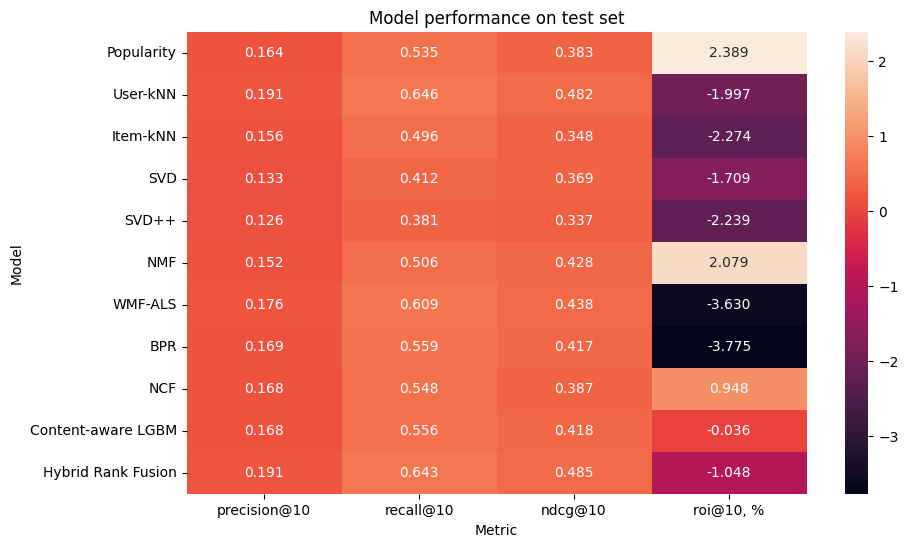

In [239]:
heatmap_df = results_df.copy()
heatmap_df["roi@10"] = heatmap_df["roi@10"] * 100
heatmap_test = heatmap_df[heatmap_df["split"] == "test"].set_index("model")[["precision@10", "recall@10", "ndcg@10", "roi@10"]]
heatmap_test = heatmap_test.rename(columns={"roi@10": "roi@10, %"})
plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_test,
    annot=True,
    fmt=".3f",
    cmap="rocket",
)
plt.title("Model performance on test set")
plt.ylabel("Model")
plt.xlabel("Metric")
plt.show()

Объяснимость рекомендаций

In [240]:
def explain_hybrid_user(user_id, recommendation_dicts, weights, k=10, candidate_k=50):
    rows = []
    item_scores = {}

    for model_name, recs_dict in recommendation_dicts.items():
        weight = weights[model_name]
        recs = recs_dict.get(user_id, [])[:candidate_k]

        for rank, item in enumerate(recs):
            contribution = weight / (rank + 1)

            if item not in item_scores:
                item_scores[item] = 0.0

            item_scores[item] += contribution

            rows.append({
                "ISIN": item,
                "model": model_name,
                "rank": rank + 1,
                "weight": weight,
                "contribution": contribution,
            })

    contrib_df = pd.DataFrame(rows)

    final_scores = (
        contrib_df
        .groupby("ISIN")["contribution"]
        .sum()
        .sort_values(ascending=False)
        .head(k)
        .reset_index()
        .rename(columns={"contribution": "hybrid_score"})
    )

    explanation_df = contrib_df.merge(
        final_scores[["ISIN"]],
        on="ISIN",
        how="inner",
    )

    return final_scores, explanation_df

In [241]:
user_id = test_binary_matrix.index[0]

final_scores, explanation_df = explain_hybrid_user(
    user_id=user_id,
    recommendation_dicts=hybrid_models_test,
    weights=best_hybrid_weights,
    k=10,
    candidate_k=50,
)

final_scores

,ISIN,hybrid_score
0,GRS434003000,0.820000
1,GRS359353000,0.407143
2,GRS245213004,0.266667
3,GRS014003032,0.261538
4,GRS003003035,0.225000
5,GRS518003009,0.175385
6,GRS015003007,0.145833
7,GRS260333000,0.122286
8,GRS419003009,0.113333
9,GRS393503008,0.103175


In [242]:
explanation_df.sort_values(["ISIN", "contribution"], ascending=[True, False])

,ISIN,model,rank,weight,contribution
3,GRS003003035,User-kNN,4,0.8,0.200000
12,GRS003003035,NMF,8,0.2,0.025000
10,GRS014003032,NMF,1,0.2,0.200000
9,GRS014003032,User-kNN,13,0.8,0.061538
5,GRS015003007,User-kNN,6,0.8,0.133333
16,GRS015003007,NMF,16,0.2,0.012500
2,GRS245213004,User-kNN,3,0.8,0.266667
25,GRS245213004,Content-aware LGBM,21,0.0,0.000000
6,GRS260333000,User-kNN,7,0.8,0.114286
17,GRS260333000,NMF,25,0.2,0.008000


In [244]:
item_id = final_scores.iloc[0]["ISIN"]
explanation_df[
    explanation_df["ISIN"] == item_id
].sort_values("contribution", ascending=False)

,ISIN,model,rank,weight,contribution
0,GRS434003000,User-kNN,1,0.8,0.80
13,GRS434003000,NMF,10,0.2,0.02
21,GRS434003000,Content-aware LGBM,4,0.0,0.00


In [245]:
importance_df = pd.DataFrame({
    "feature": X_lgb.columns,
    "importance": content_lgbm_model.feature_importances_,
})
importance_df = importance_df.sort_values(
    "importance",
    ascending=False,
)
importance_df.head(20)

,feature,importance
6,user_avg_asset_popularity_train,2728
7,user_max_asset_popularity_train,1986
5,user_avg_interactions_per_asset_train,1840
18,industry_final,1586
4,user_total_interactions_train,1572
3,user_n_assets_train,1429
25,max_drawdown_train,669
26,last_price_train,657
22,return_180d,588
32,downside_volatility_90d,513


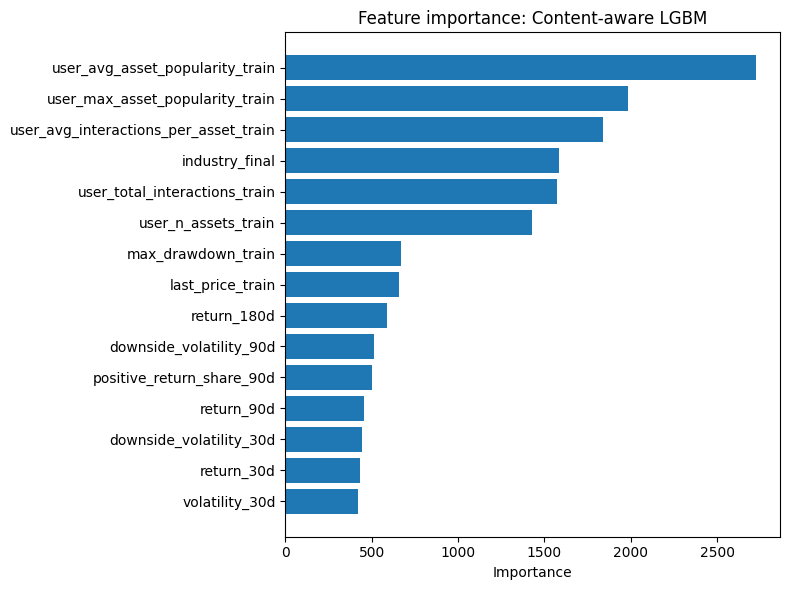

In [246]:
top_importance = importance_df.head(15).sort_values("importance")
plt.figure(figsize=(8, 6))
plt.barh(
    top_importance["feature"],
    top_importance["importance"],
)
plt.title("Feature importance: Content-aware LGBM")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

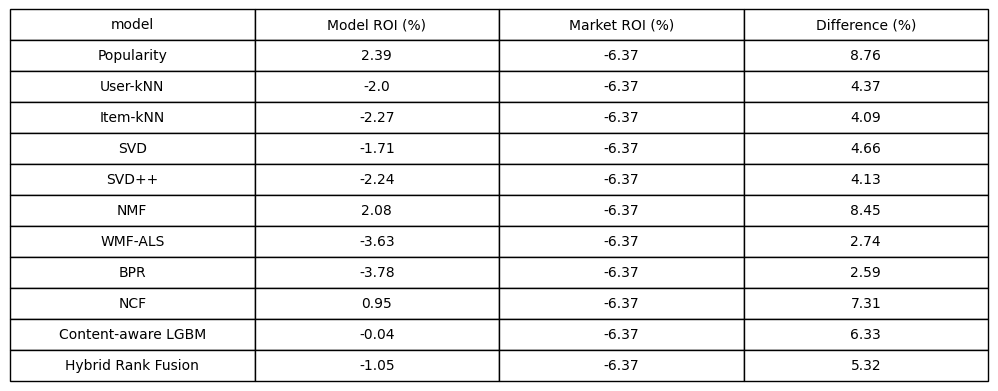

In [249]:
market_roi = pd.Series(test_item_roi).mean()
roi_table = (
    results_df[results_df["split"] == "test"]
    [["model", "roi@10"]]
    .copy()
)

roi_table["Model ROI (%)"] = roi_table["roi@10"] * 100
roi_table["Market ROI (%)"] = market_roi * 100

roi_table["Difference (%)"] = (
    roi_table["Model ROI (%)"]
    - roi_table["Market ROI (%)"]
)

roi_table = roi_table[
    ["model", "Model ROI (%)", "Market ROI (%)", "Difference (%)"]
]

roi_table = roi_table.round(2)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")

table = ax.table(
    cellText=roi_table.values,
    colLabels=roi_table.columns,
    cellLoc="center",
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)

plt.tight_layout()

plt.savefig(
    "roi_comparison_table.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()